# Laporan Pengembangan Deteksi Tutup Botol (cap / no_cap) — RVM

Proyek Kerja Praktik / Capstone — Reverse Vending Machine, PT Inastek.
Dokumen ini merangkum **seluruh** proses yang sudah dikerjakan untuk modul deteksi
ada/tidaknya tutup botol, dari pengambilan data primer sampai dua kali iterasi training.

Periode kerja: 2 – 3 September 2026.
Terakhir diperbarui: 2026-09-03.

---


## 1. Tujuan & ruang lingkup

Mesin RVM memindai botol PET di atas konveyor secara *on-the-fly*. Salah satu keputusan
sistem: **tutup botol wajib sudah dilepas**. Jika masih ada tutup → botol ditolak.

Modul yang dibangun di sini: **detektor objek 2 kelas** — `cap` (ada tutup) dan
`no_cap` (tanpa tutup), berupa bounding box ketat di area tutup/leher botol.
Basis model: **YOLOv8n** (nano), input 640×640, ekspor akhir ke **OpenVINO** untuk
inferensi di sisi desktop/mesin.

Target POV deployment: **kamera dari atas konveyor, tampak atas (top-down), botol utuh.**

---


## 2. Lingkungan & tools

| Komponen | Versi / detail |
|---|---|
| Python | 3.13 (virtualenv `venv/`) |
| Ultralytics YOLO | 8.4.54 |
| PyTorch | 2.11.0 + CUDA 12.8 |
| GPU | NVIDIA GeForce RTX 4050 Laptop (6 GB) |
| Background removal | `rembg` 2.0.81, model `u2net` |
| Segmentasi tangan | `yolov8n-seg` (kelas `person`, COCO) |
| OpenCV | 4.13.0 |
| Augmentasi | hand-rolled (cv2 + numpy); `albumentations` tidak dipakai |
| Barcode (modul terpisah) | `zxing-cpp` 3.1.1 + `cv2.barcode` (bukan bagian laporan ini) |

Semua script berada di `datasets/`. Model & dataset **tidak** di-commit ke git
(`datasets/` masuk `.gitignore`).

---


## 3. Data primer — `shoot_v1`

### 3.1 Pengambilan

- **13 botol**, **20 foto per botol** = **260 foto**, kamera HP (Redmi Note 11 Pro, 108 MP).
- Latar: kain fleece cokelat gelap, 2 sumber cahaya diffuse (lampu kamar samping + lampu baca).
  Setup ini menghasilkan cutout `rembg` yang bersih.
- Botol (urut shoot):

  | # | Merek | Ukuran |
  |---|---|---|
  | b01 | Le Mineral | besar |
  | b02 | Aqua | tanggung |
  | b03 | Nestlé Pure Life | besar |
  | b04 | Crystalin | tanggung |
  | b05 | Natsbee Honey Orange | tanggung |
  | b06 | Air Mineral Alfamart | besar |
  | b07 | Cleo | besar |
  | b08 | Big Cola Lemon Lime | 1 L |
  | b09 | Big Cola | 1 L |
  | b10 | Big Cola Nipis Madu | 1 L |
  | b11 | Minyak Tropical | 1 L |
  | b12 | Isoplus | tanggung |
  | b13 | Le Mineral | tanggung |

- Pola 20 foto per botol (b02–b13): 10 kondisi `cap` + 10 kondisi `no_cap`, tiap 10 terdiri:
  - slot 01–03: **top-down**, botol tidak diangkat, 3 sisi unik (bahan calon training deteksi merek)
  - slot 04–08: **lift45** — botol diangkat ~45° sumbu-y, dirotasi arah N / NE / E / SE / S
  - slot 09–10: **side45** — kamera dari sisi 45°, tutup di atas & tutup di bawah
  - b01 memakai penomoran slot generik (tanpa nama slot) — jadi kasus khusus di pipeline.

### 3.2 Organisasi & pelabelan

- Foto 108 MP asli disimpan di `datasets/shoot_v1_raw/` (~1,37 GB) → aman dihapus dari HP.
- Di-*downscale* ke ~2 MP, dirapikan ke folder per-botol `b01_…` … `b13_…` (`datasets/shoot_v1/`),
  + `MANIFEST.csv` (file, bottle_no, merek, ukuran, cap_state, slot, nama_slot, nama_asli).
- Pelabelan bounding box tutup: **semua ~260 box dikoreksi manual** oleh mahasiswa.
  Semua pendekatan auto-label heuristik (blob warna, `rembg` whole-bottle box, COCO
  "bottle" box, "ujung lebih sempit = tutup") **ditolak** karena mayoritas box tidak pas
  di area tutup. Kesimpulan: untuk box ketat & konsisten, heuristik tidak memadai — perlu
  model-in-the-loop atau tool berbantuan model (Roboflow / CVAT / Label Studio ML backend).
- Hasil bersih: `datasets/cap_shoot_v1/` — 260 gambar 2 MP + 260 label YOLO
  (**130 `cap` / 130 `no_cap`**, 0 kosong) + `data.yaml`.

---


## 4. Pipeline cutout botol (`cutout_shoot.py`, `salvage_held.py`)

Tujuan: memotong botol bersih dari latar untuk dipakai *cut-and-paste augmentation*.

### 4.1 Pemisahan by pose

Aturan seragam berdasarkan **nomor slot** (bukan substring nama slot — b01 tidak punya
nama slot):

| slot | pose | kategori |
|---|---|---|
| 01–03 | top-down, botol tak diangkat | `nohand/` — tanpa tangan |
| 04–10 | lift45 / side45, botol dipegang | `held/` — ada tangan bersarung |

Cutout: `rembg u2net` (downscale 900 px dulu, alpha matting **off** — matting OOM di
gambar besar), ambil connected-component terbesar, crop ketat + pad 4 %, simpan RGBA PNG.
Label cap-box ditransform ke koordinat crop.

Hasil: `nohand/` = **78** cutout bersih, `held/` = **182** cutout (masih ada tangan).

### 4.2 Penyelamatan cutout ber-tangan (`salvage_held.py`)

Tangan bersarung oranye menyatu dengan blob botol di mask `rembg`. Metode:
`blob rembg` **dikurangi** (`yolov8n-seg` mask kelas *person* ∪ mask HSV oranye ketat),
area cap-box dilindungi (skip HSV untuk b05 Natsbee yang botolnya oranye).

Hasil dipartisi otomatis berdasarkan `kept_frac` (porsi botol tersisa setelah tangan dibuang):

| folder | jumlah | kondisi |
|---|---|---|
| `held_nohand/` | 77 → **71** | `kept_frac` ≥ 0,80 — bersih, tangan hilang |
| `held_nohand/_marginal/` | 42 | 0,55–0,80 — badan botol termakan sebagian, tutup umumnya utuh |
| `held_nohand/_damaged/` | 63 | < 0,55 — **tidak tertolong**, tangan menutupi terlalu banyak |

Catatan penting: **63 cutout `_damaged` tidak bisa dipulihkan** — piksel di balik genggaman
tangan memang tidak ada; tidak ada algoritma yang bisa mengembalikannya. Kalau POV lift45/side45
itu dibutuhkan, solusinya shoot ulang dengan botol disangga (tanpa dipegang), bukan menambah algoritma.

### 4.3 Verifikasi akhir bebas tangan (`verify_nohand.py`)

Cek ulang 155 cutout "bersih" (nohand 78 + held_nohand 77) dengan HSV oranye + `person`-seg.
15 keflag → **9 false-positive** (logo palem TROPICAL, cairan cokelat Isoplus, foto atlet
di label Big Cola — bukan sarung tangan) dikembalikan; **6 asli ber-tangan** dikarantina ke
`held_nohand/_hand_residual/`.

### 4.4 Hasil akhir cutout

| set | jumlah | cap | no_cap |
|---|---|---|---|
| `nohand/` (top-down) | 78 | 39 | 39 |
| `held_nohand/` (salvage lift/side) | 71 | 33 | 38 |
| **Total input compositing** | **149** | **72** | **77** |

Sebaran per botol merata: b01–b13 masing-masing 10–14 cutout.

---


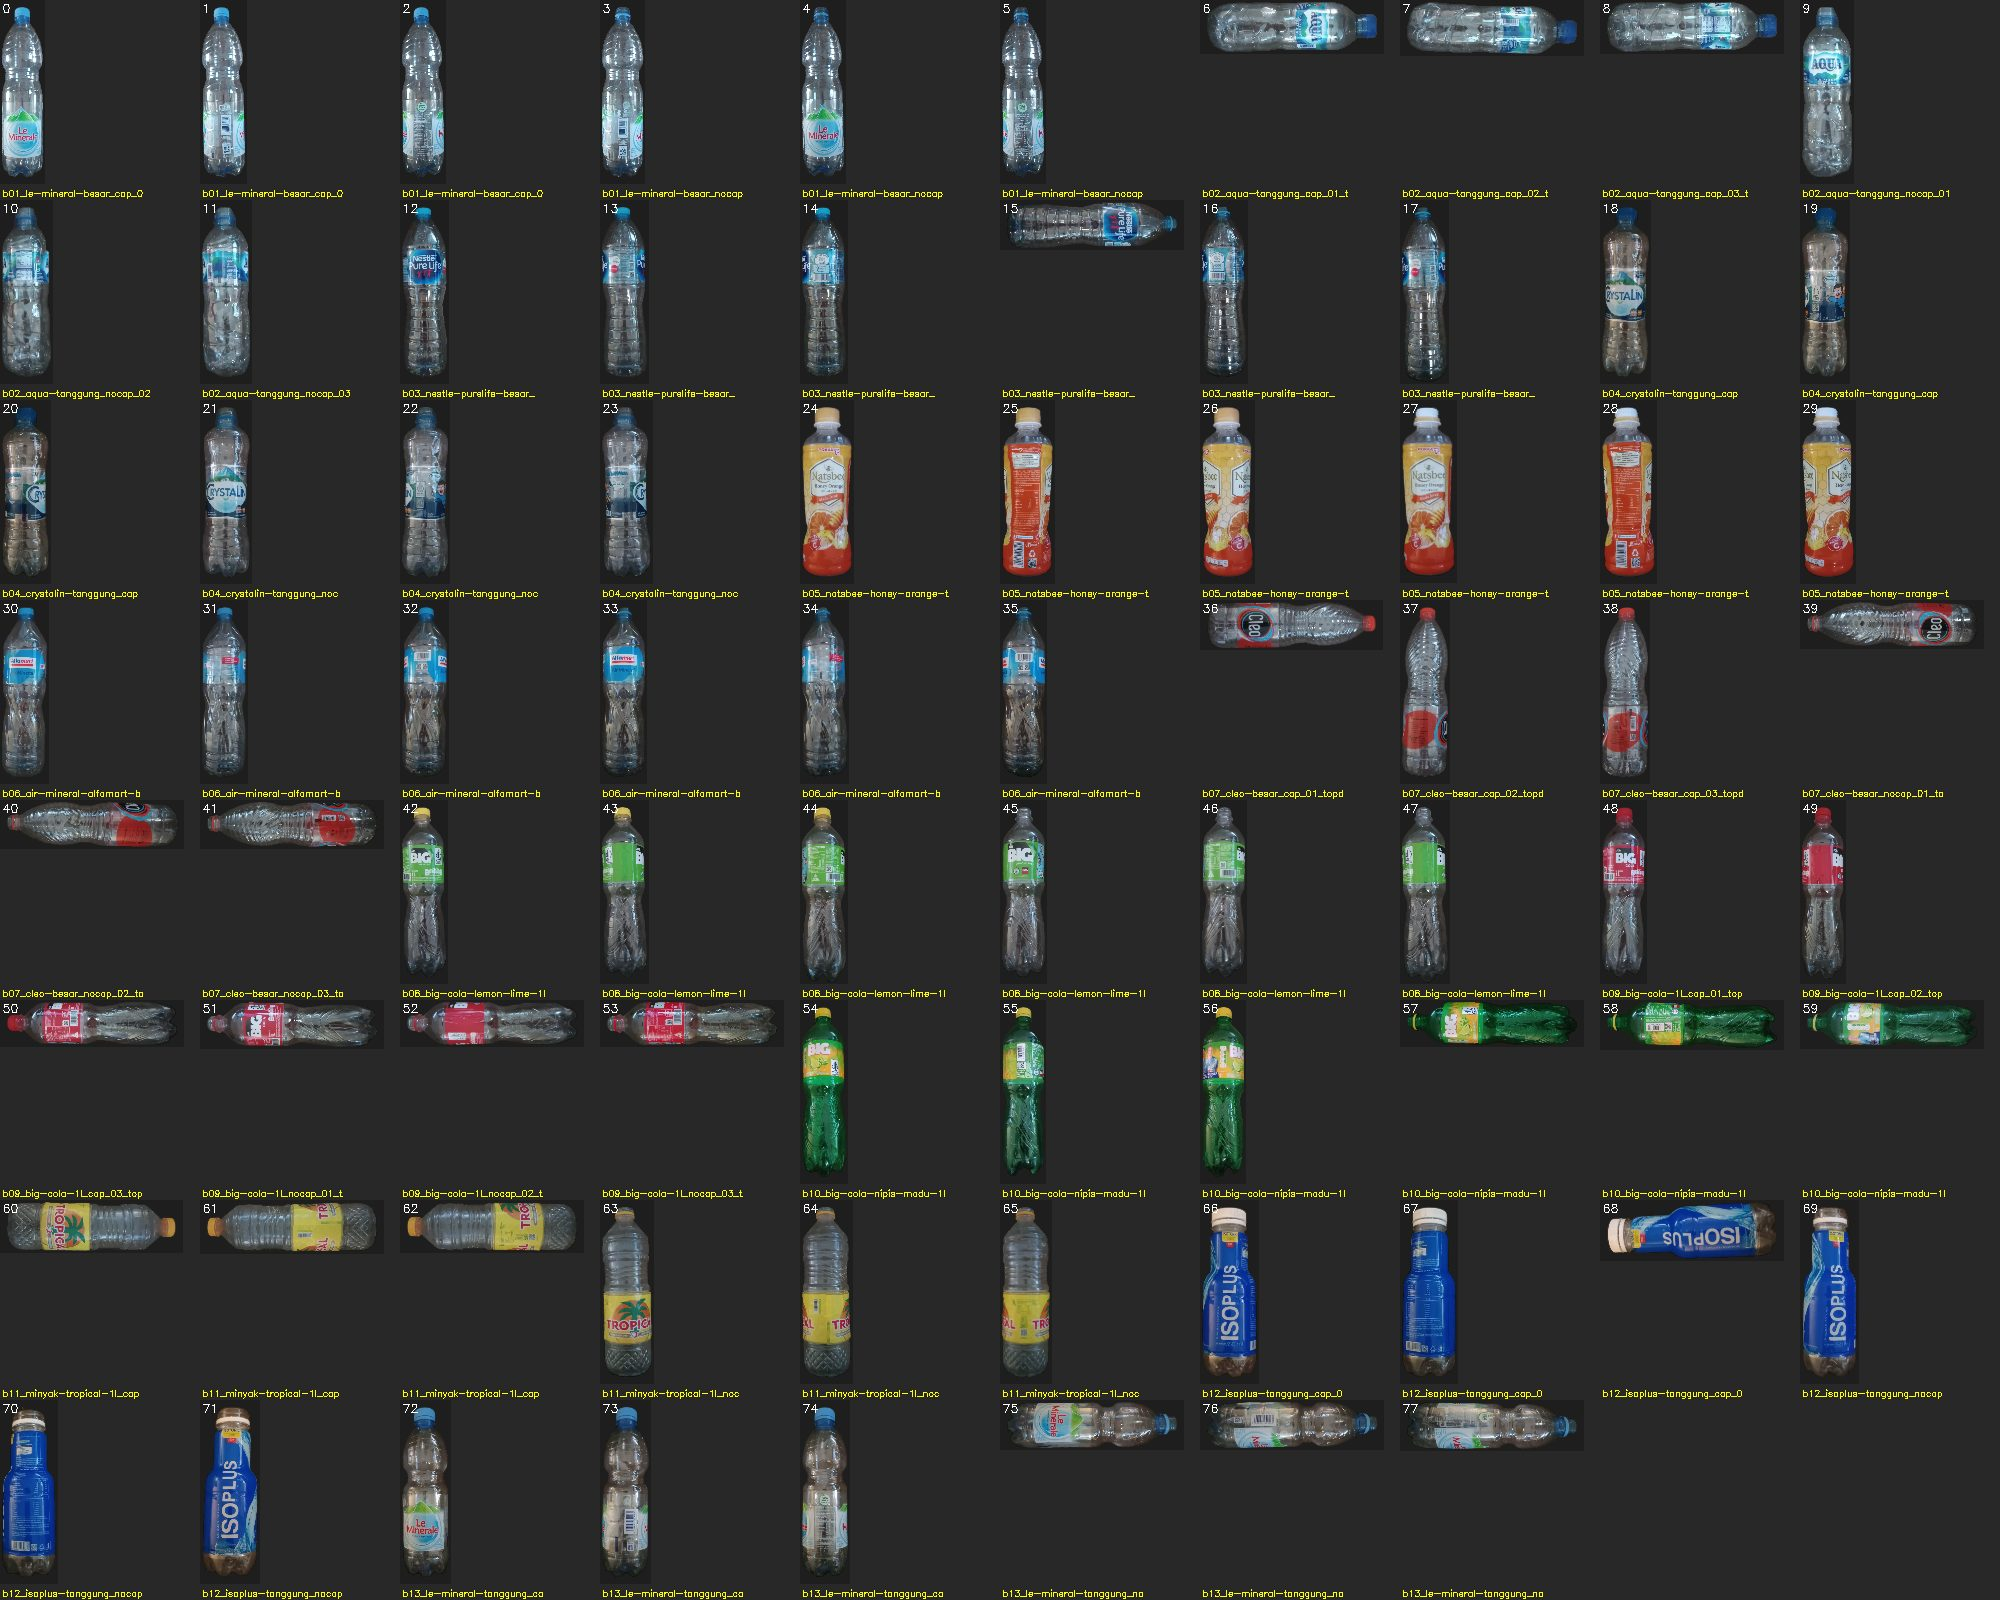

*Contact sheet 78 cutout `nohand/` (top-down, tanpa tangan).*


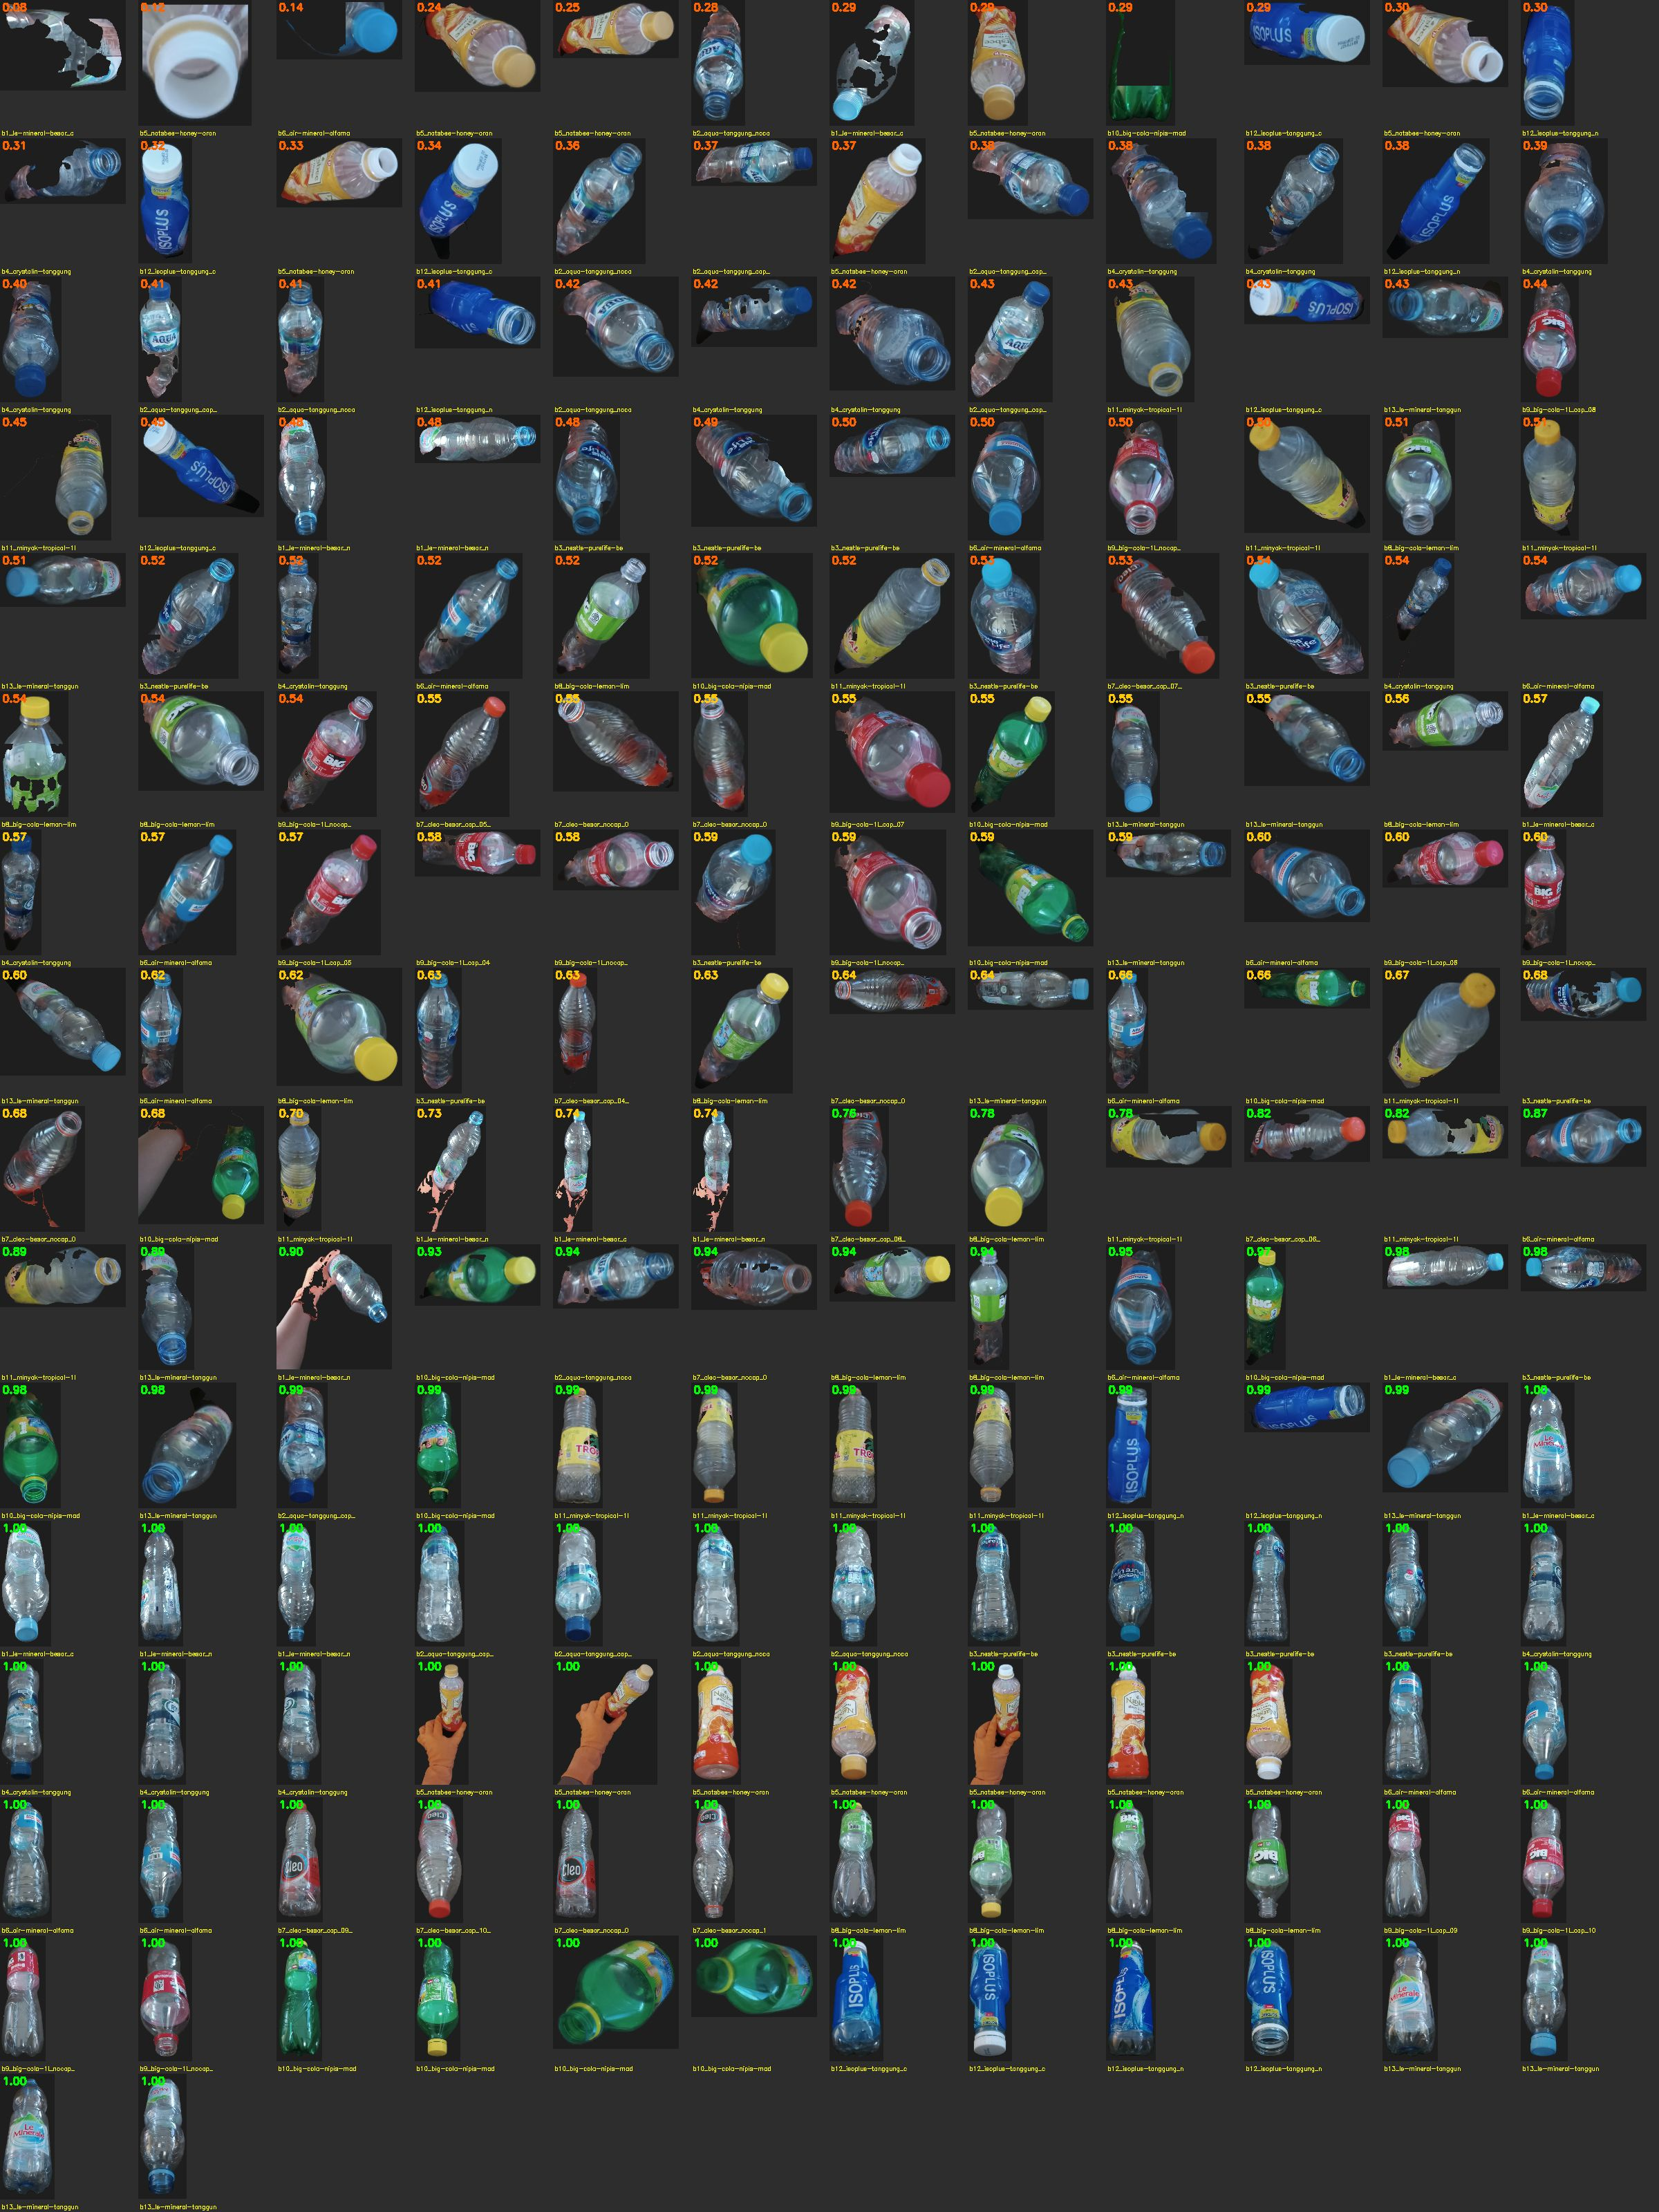

*182 cutout `held_nohand/` setelah tangan dibuang, diurut `kept_frac` (jelek→bagus). Hijau ≥0,90 bersih; oranye <0,55 tidak tertolong.*


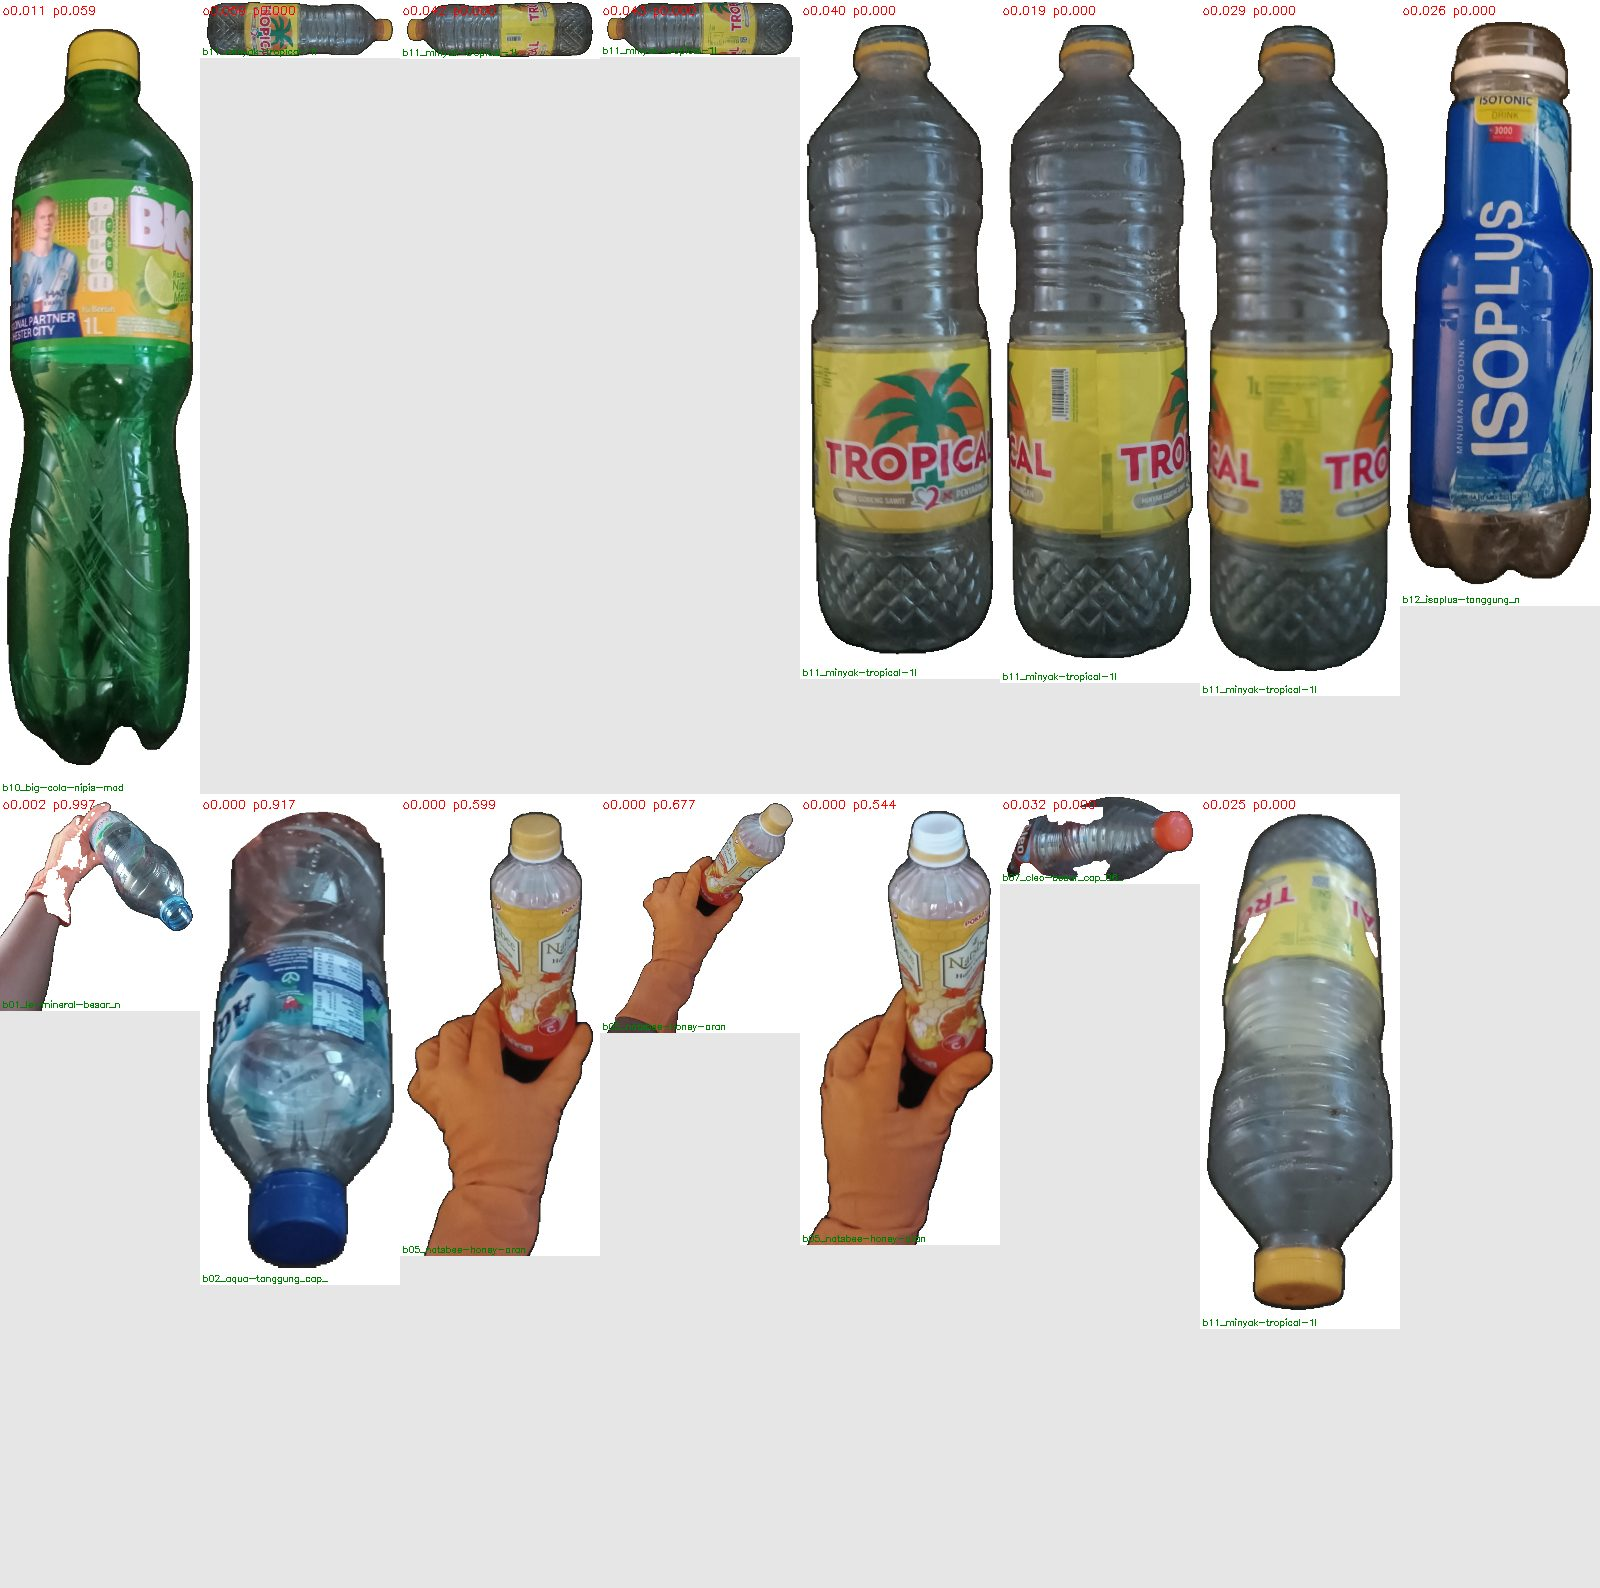

*15 cutout keflag di verifikasi akhir — 9 false-positive (logo/cap oranye) dikembalikan, 6 asli ber-tangan dikarantina.*


## 5. Data sekunder — `bottle_cap_base/conveyor/`

Dataset publik botol-di-konveyor (proxy; belt hitam, bukan belt hijau mesin sebenarnya):

| sumber | cap | no_cap | keterangan |
|---|---|---|---|
| `bc_` | 913 | 0 | "Pet black convey" — top-down belt hitam, POV paling mirip RVM |
| `mp_` | 365 | 39 | meja putih, menyudut |
| `rg_` | 77 | 70 | ruang gelap |
| **total** | **1.355** | **109** | label cap-box sudah **tight** (median 5–17 % lebar frame) |

`_by_cap_color/` = 1.355 gambar `conveyor/cap` yang sama, diindeks per warna tutup:
green 365, cyan_teal 290, orange_yellow 211, blue 167, grey 138, red 126, black 29, white_clear 29.

Pool closeup (`good/` 9.104, `medium/` 175, `low/` 447 — foto tutup jarak dekat) **tidak
dipakai**: eksperimen sebelumnya (`full_only` vs `combined`) membuktikan data closeup **tidak
transfer** ke POV konveyor dan bisa menurunkan performa.

---


## 6. Pipeline dataset sintetis (`make_synth.py`)

Metode: **cut-and-paste augmentation** (Dwibedi 2017, Ghiasi 2021).

### 6.1 Background — 100 % di-generate, semua warna acak (opsi A)

Keputusan eksplisit: **tidak** memakai foto konveyor asli sebagai background. Alasan:
model harus belajar botol/tutupnya, bukan menghafal background. Belt asli mesin hijau,
tetapi dipilih variasi warna penuh untuk robustness maksimal.

Background di-generate fresh tiap gambar (≈ jumlah gambar = jumlah background unik):
- solid random (HSV penuh) + noise
- gradient 2–3 warna, linear & radial, arah acak
- garis/slat miring acak (menyerupai belt)
- soft blobs perlin-ish
- checker
- + brightness/contrast acak lebar + vignette (p 0,3)

### 6.2 Compositing per gambar

- rotate-keep (kanvas diperbesar, tidak ada clipping); sudut ~ N(0, 18°) clip ±42°,
  8 % kemungkinan ±180°
- skala: sisi terpanjang botol = 30–82 % dimensi frame
- posisi acak penuh di dalam frame
- jitter fotometrik per-botol (brightness/contrast/HSV)
- bayangan offset lembut
- 15 % gambar berisi 2 botol
- coarse-dropout di area botol (p 0,22) — robust ke oklusi

### 6.3 Augmentasi full-frame

perspektif ringan (p 0,25, box ikut ditransform), motion blur, gaussian blur, gaussian +
ISO noise, brightness/contrast, HSV shift, CLAHE (p 0,15), shadow poligon (p 0,25),
JPEG re-compress kualitas acak.

Cap-box ditransform lewat **setiap** tahap geometrik (matrix rotasi → skala → translasi →
homografi perspektif), lalu di-clip ke frame, dibuang jika < 4 px.

### 6.4 Split

**Grouped split by cutout-stem**, 80 / 10 / 10, stratified per kelas — semua varian dari
satu cutout tetap di satu split (anti *augmentation leak*). Data conveyor di-group by
*burst key* (`bc_KakaoTalk_<timestamp>`).

### 6.5 Fold-in conveyor (`add_conveyor.py` + `add_nocap.py`)

- cap: disampling **balanced per warna** ~130/warna (black & white_clear cuma 29) = **834** real cap
- no_cap: **semua 109** real no_cap (mp 39 + rg 70)
- di-resize 640×640, disalin dengan prefix `cv_` ke split yang sama

> Catatan bug: `add_conveyor.py` punya bug pemisah path Windows (`\images\` vs `/images/`)
> yang melewatkan no_cap → diperbaiki oleh `add_nocap.py`.

---


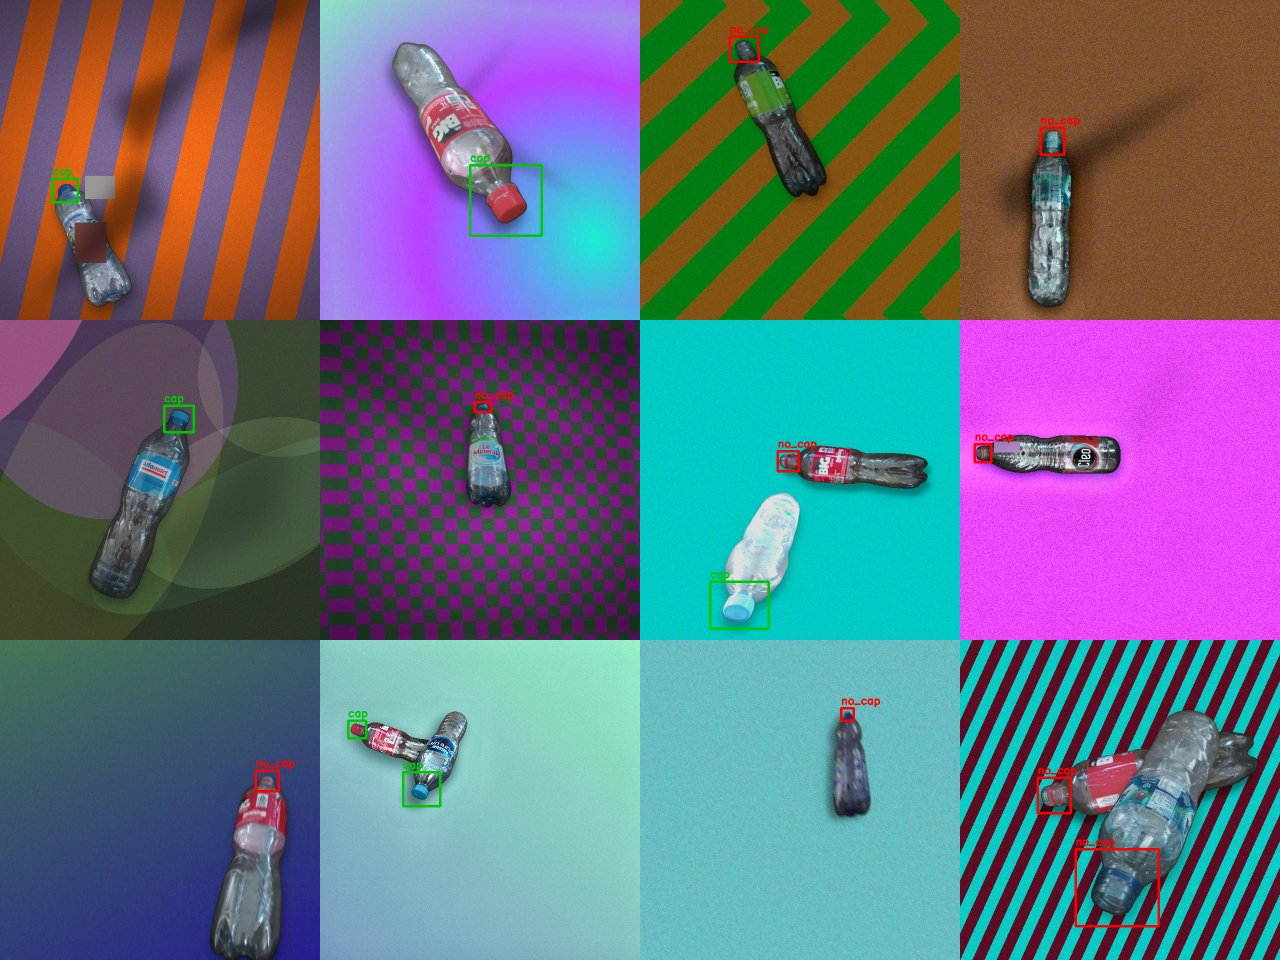

*Contoh 12 gambar sintetis `synth_cap_v1` (train) dengan ground-truth box. Background 100% di-generate, warna acak; botol dirotasi/diskala/didegradasi.*


## 7. Iterasi v1 — `synth_cap_v1_640`

### 7.1 Komposisi dataset

Variasi: cap ×28, no_cap ×36 per cutout.

| split | gambar | box cap | box no_cap | sintetis | conveyor |
|---|---|---|---|---|---|
| train | 4.584 | 2.605 | 2.576 | 3.792 | 792 |
| val | 495 | 265 | 297 | 448 | 47 |
| test | 652 | 351 | 373 | 548 | 104 |
| **TOTAL** | **5.731** | **3.221** | **3.246** | 4.788 | 943 |

### 7.2 Konfigurasi training (`train_synth.py`)

`YOLOv8n` (dari `bottle_cap_base/yolov8n.pt`), imgsz 640, epochs 100, batch 16,
patience 30, workers 2, cache off, `close_mosaic` 10, seed 0, device 0.
Durasi: **1,35 jam** (100 epoch penuh, tidak early-stop).

### 7.3 Hasil

| | P | R | mAP@50 | mAP@50-95 |
|---|---|---|---|---|
| **val** (best.pt, 495 img) | 0,986 | 0,977 | 0,986 | 0,762 |
| — cap | 0,992 | 0,985 | 0,994 | 0,798 |
| — no_cap | 0,981 | 0,970 | 0,979 | 0,726 |
| **test** (652 img) | 0,978 | 0,947 | **0,981** | 0,718 |
| — cap | 0,979 | 0,938 | 0,980 | 0,714 |
| — no_cap | 0,977 | 0,957 | 0,982 | 0,722 |

Kurva loss train & val turun mulus, metrik plateau ~epoch 40–50, gap val→test kecil & sehat
(tidak overfit). Inferensi 2,4 ms/gambar (GPU).

**Interpretasi:** angka tinggi ini membuktikan **task composited-nya berhasil dipelajari**.
Test set masih sintetis + conveyor, **bukan** holdout belt asli murni.

### 7.4 Evaluasi kualitatif & live

- **24 foto conveyor top-down (belt hitam):** 24/24 terdeteksi, box ketat di area tutup,
  conf 0,80–0,89, tahan botol miring/gepeng/beda merek.
  *Caveat:* sumber `cap_conveyor_raw` sebagian tumpang tindih dengan data training → bukan holdout bersih.
- **Live webcam (POV top-down botol):** kuat.
- **Live webcam (POV sejajar mata, botol dipegang):** **gagal total** (0 deteksi bahkan
  di conf 0,05) — POV ini di luar distribusi training (cutout composited + conveyor top-down),
  dan memang bukan POV deployment.
- **Temuan dari mahasiswa:** `no_cap` confidence kadang kecil dan **flip jadi `cap`** saat
  gambar webcam buram / kualitas kamera rendah.

---


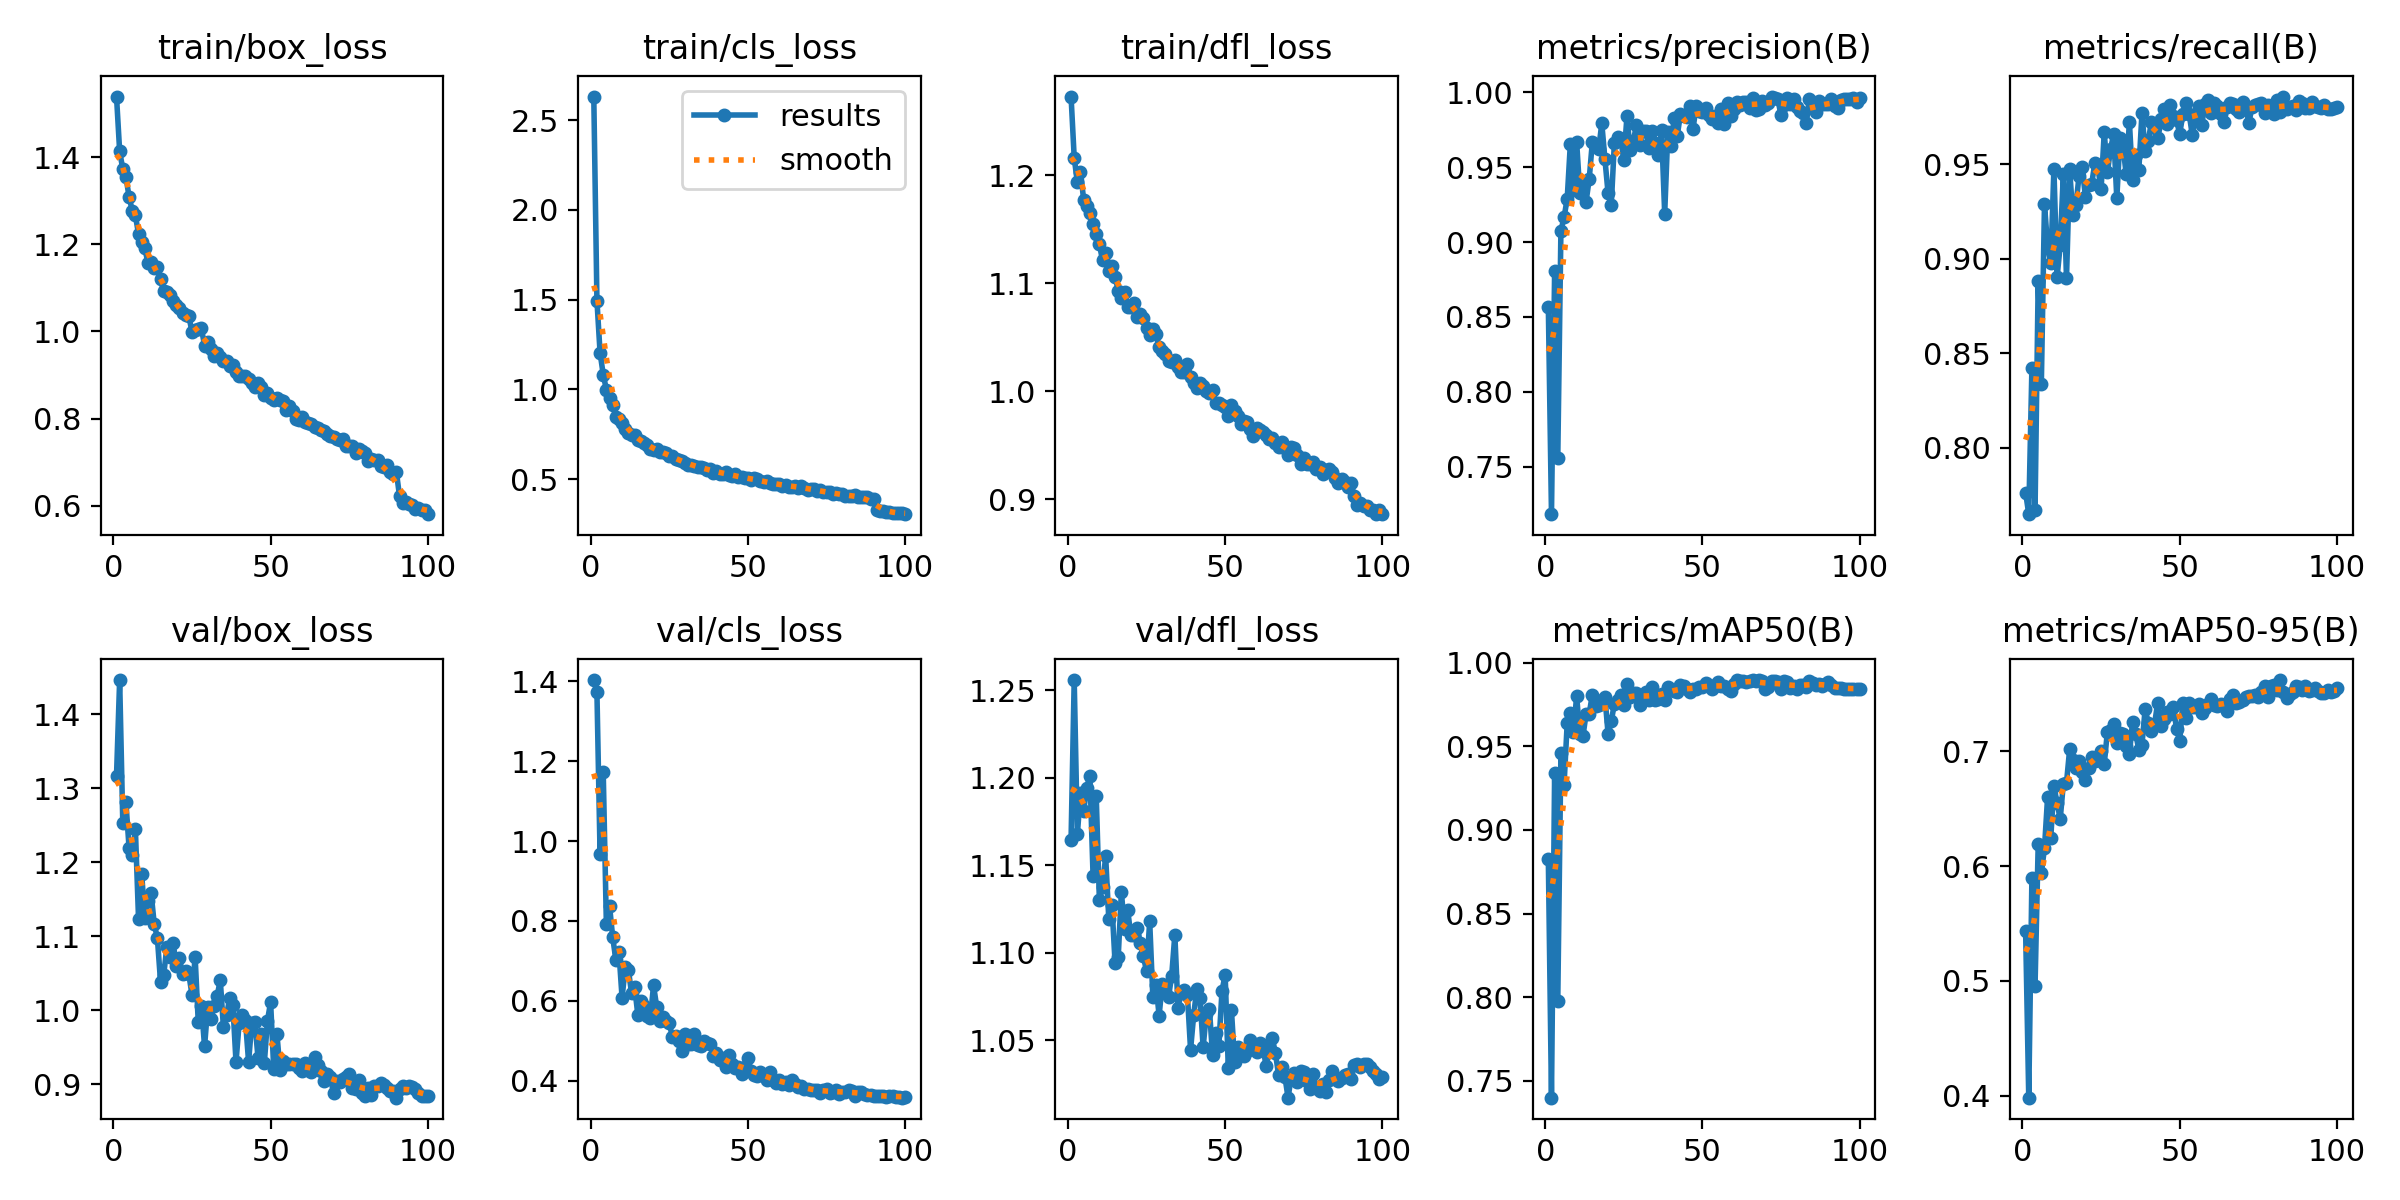

*v1 — kurva training 100 epoch. Loss train & val turun mulus, metrik plateau ~epoch 40–50, tidak overfit.*


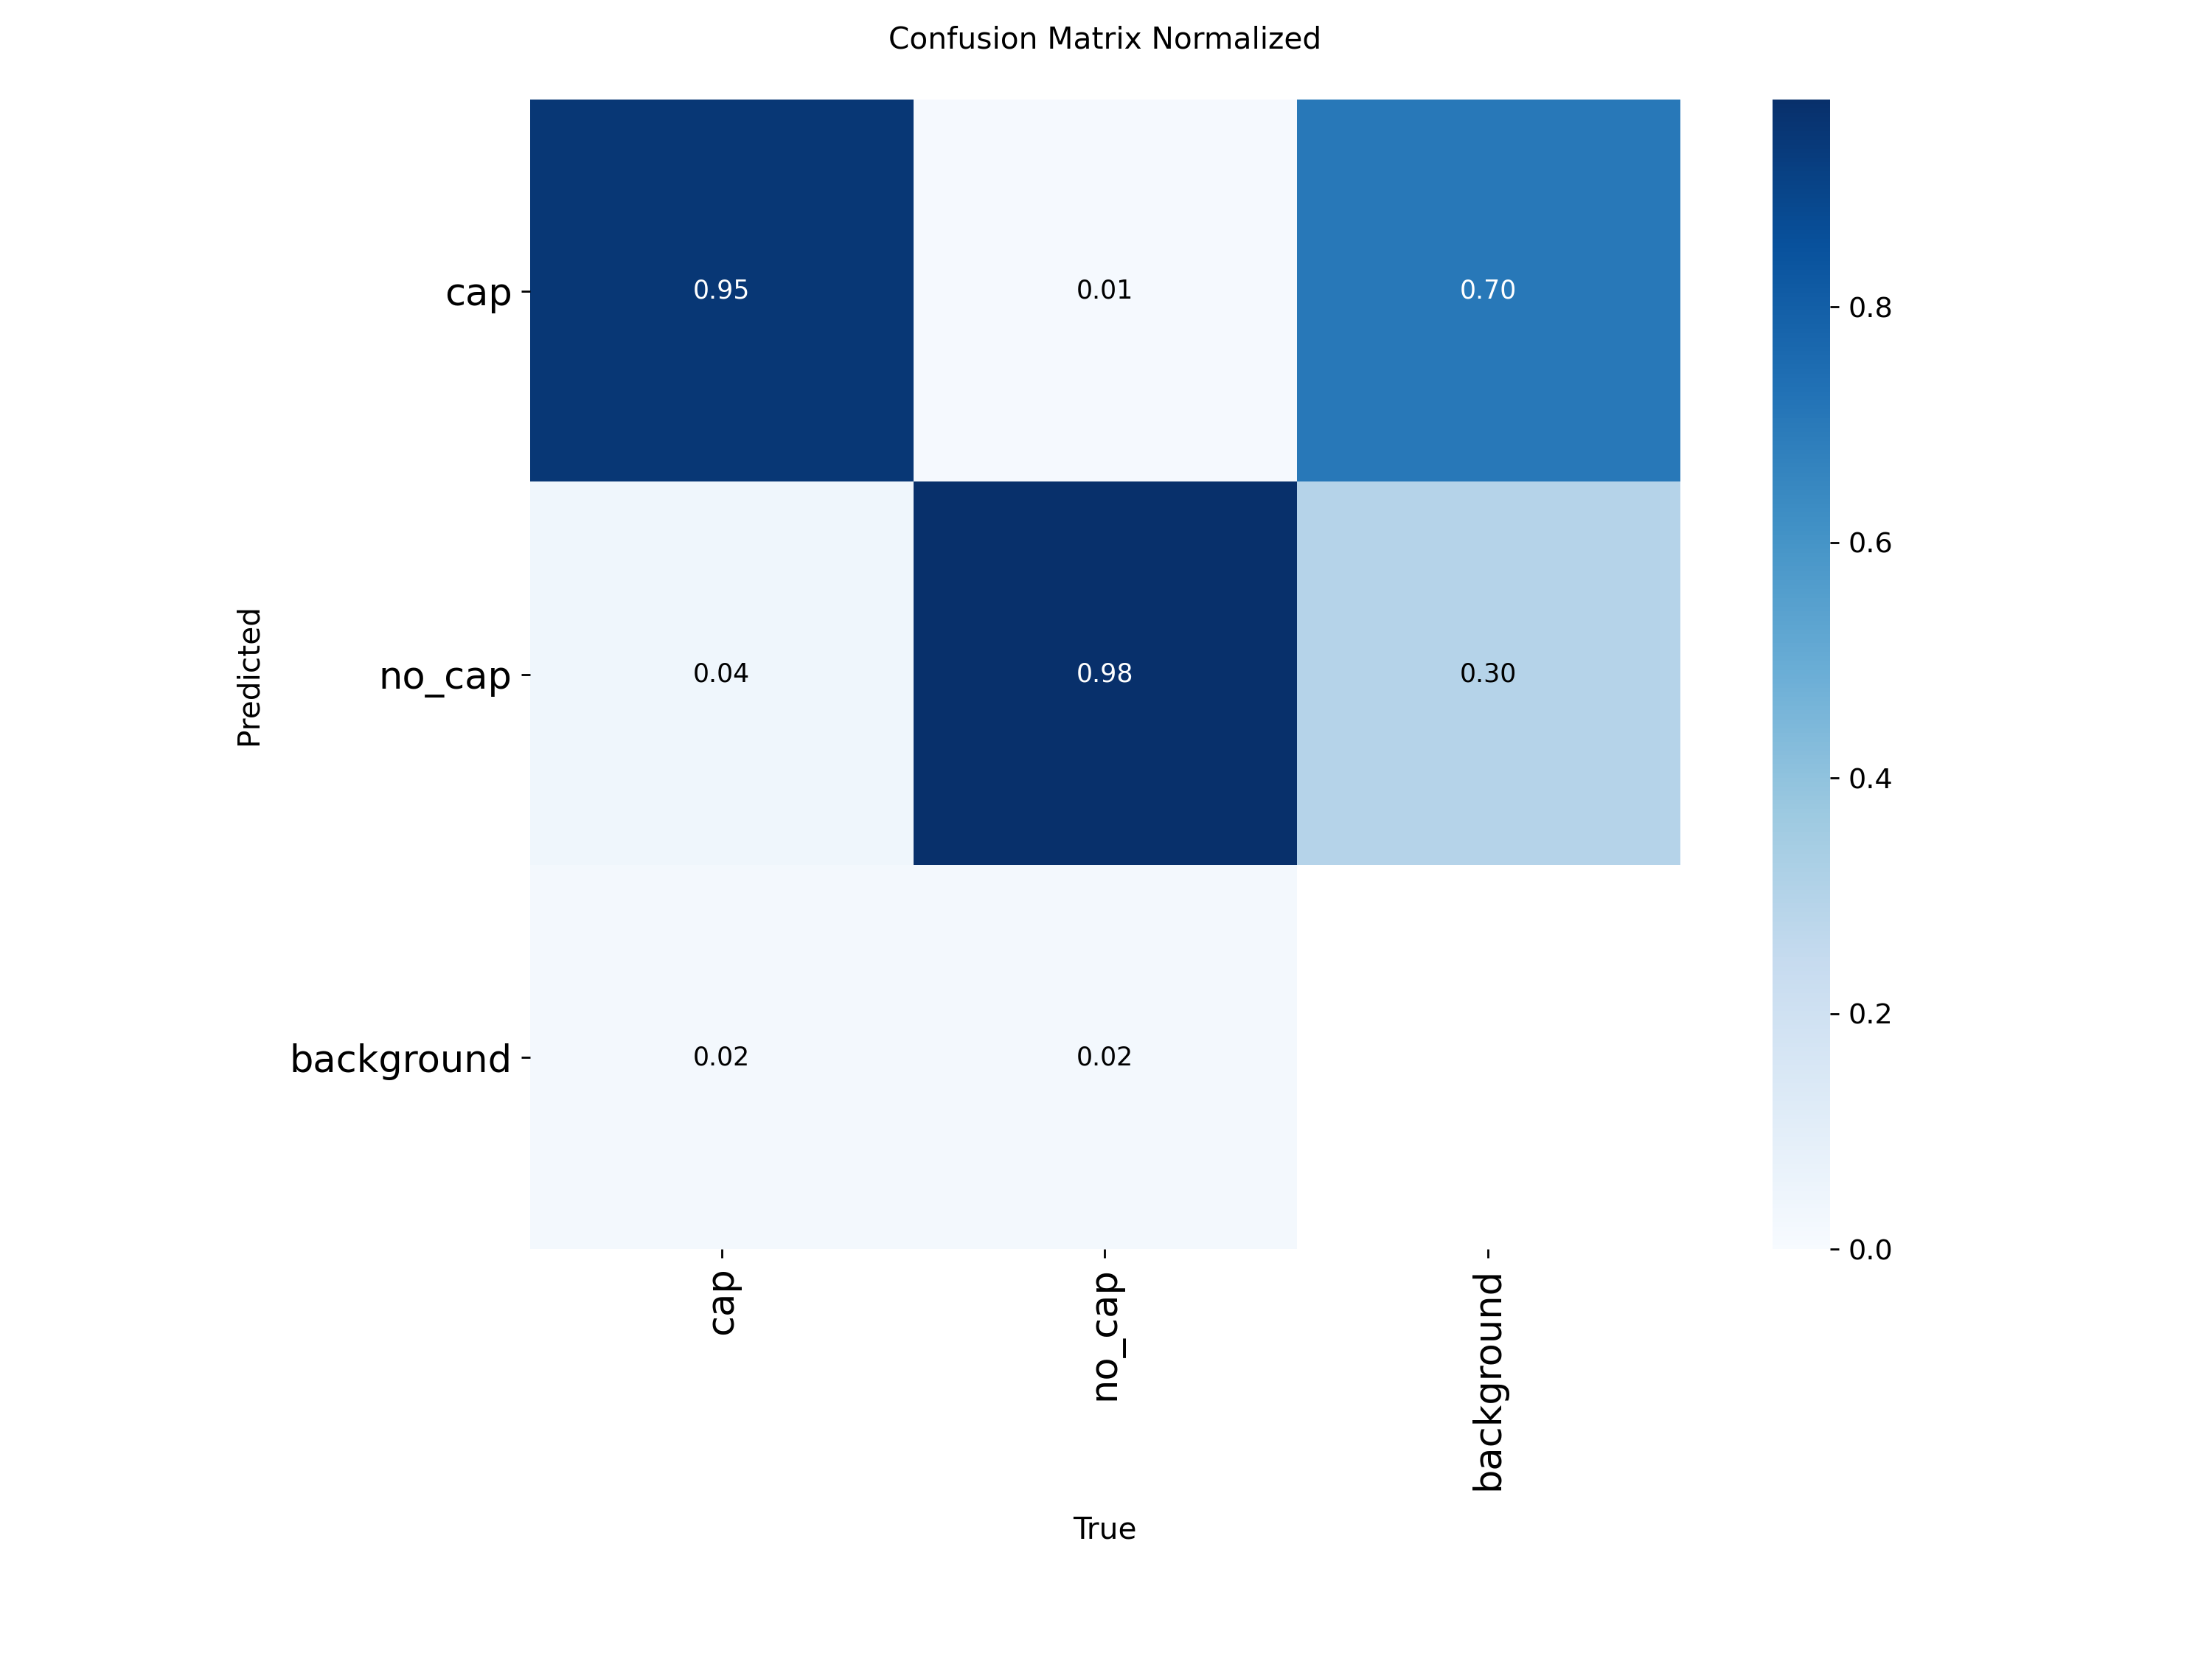

*v1 — confusion matrix di TEST split.*


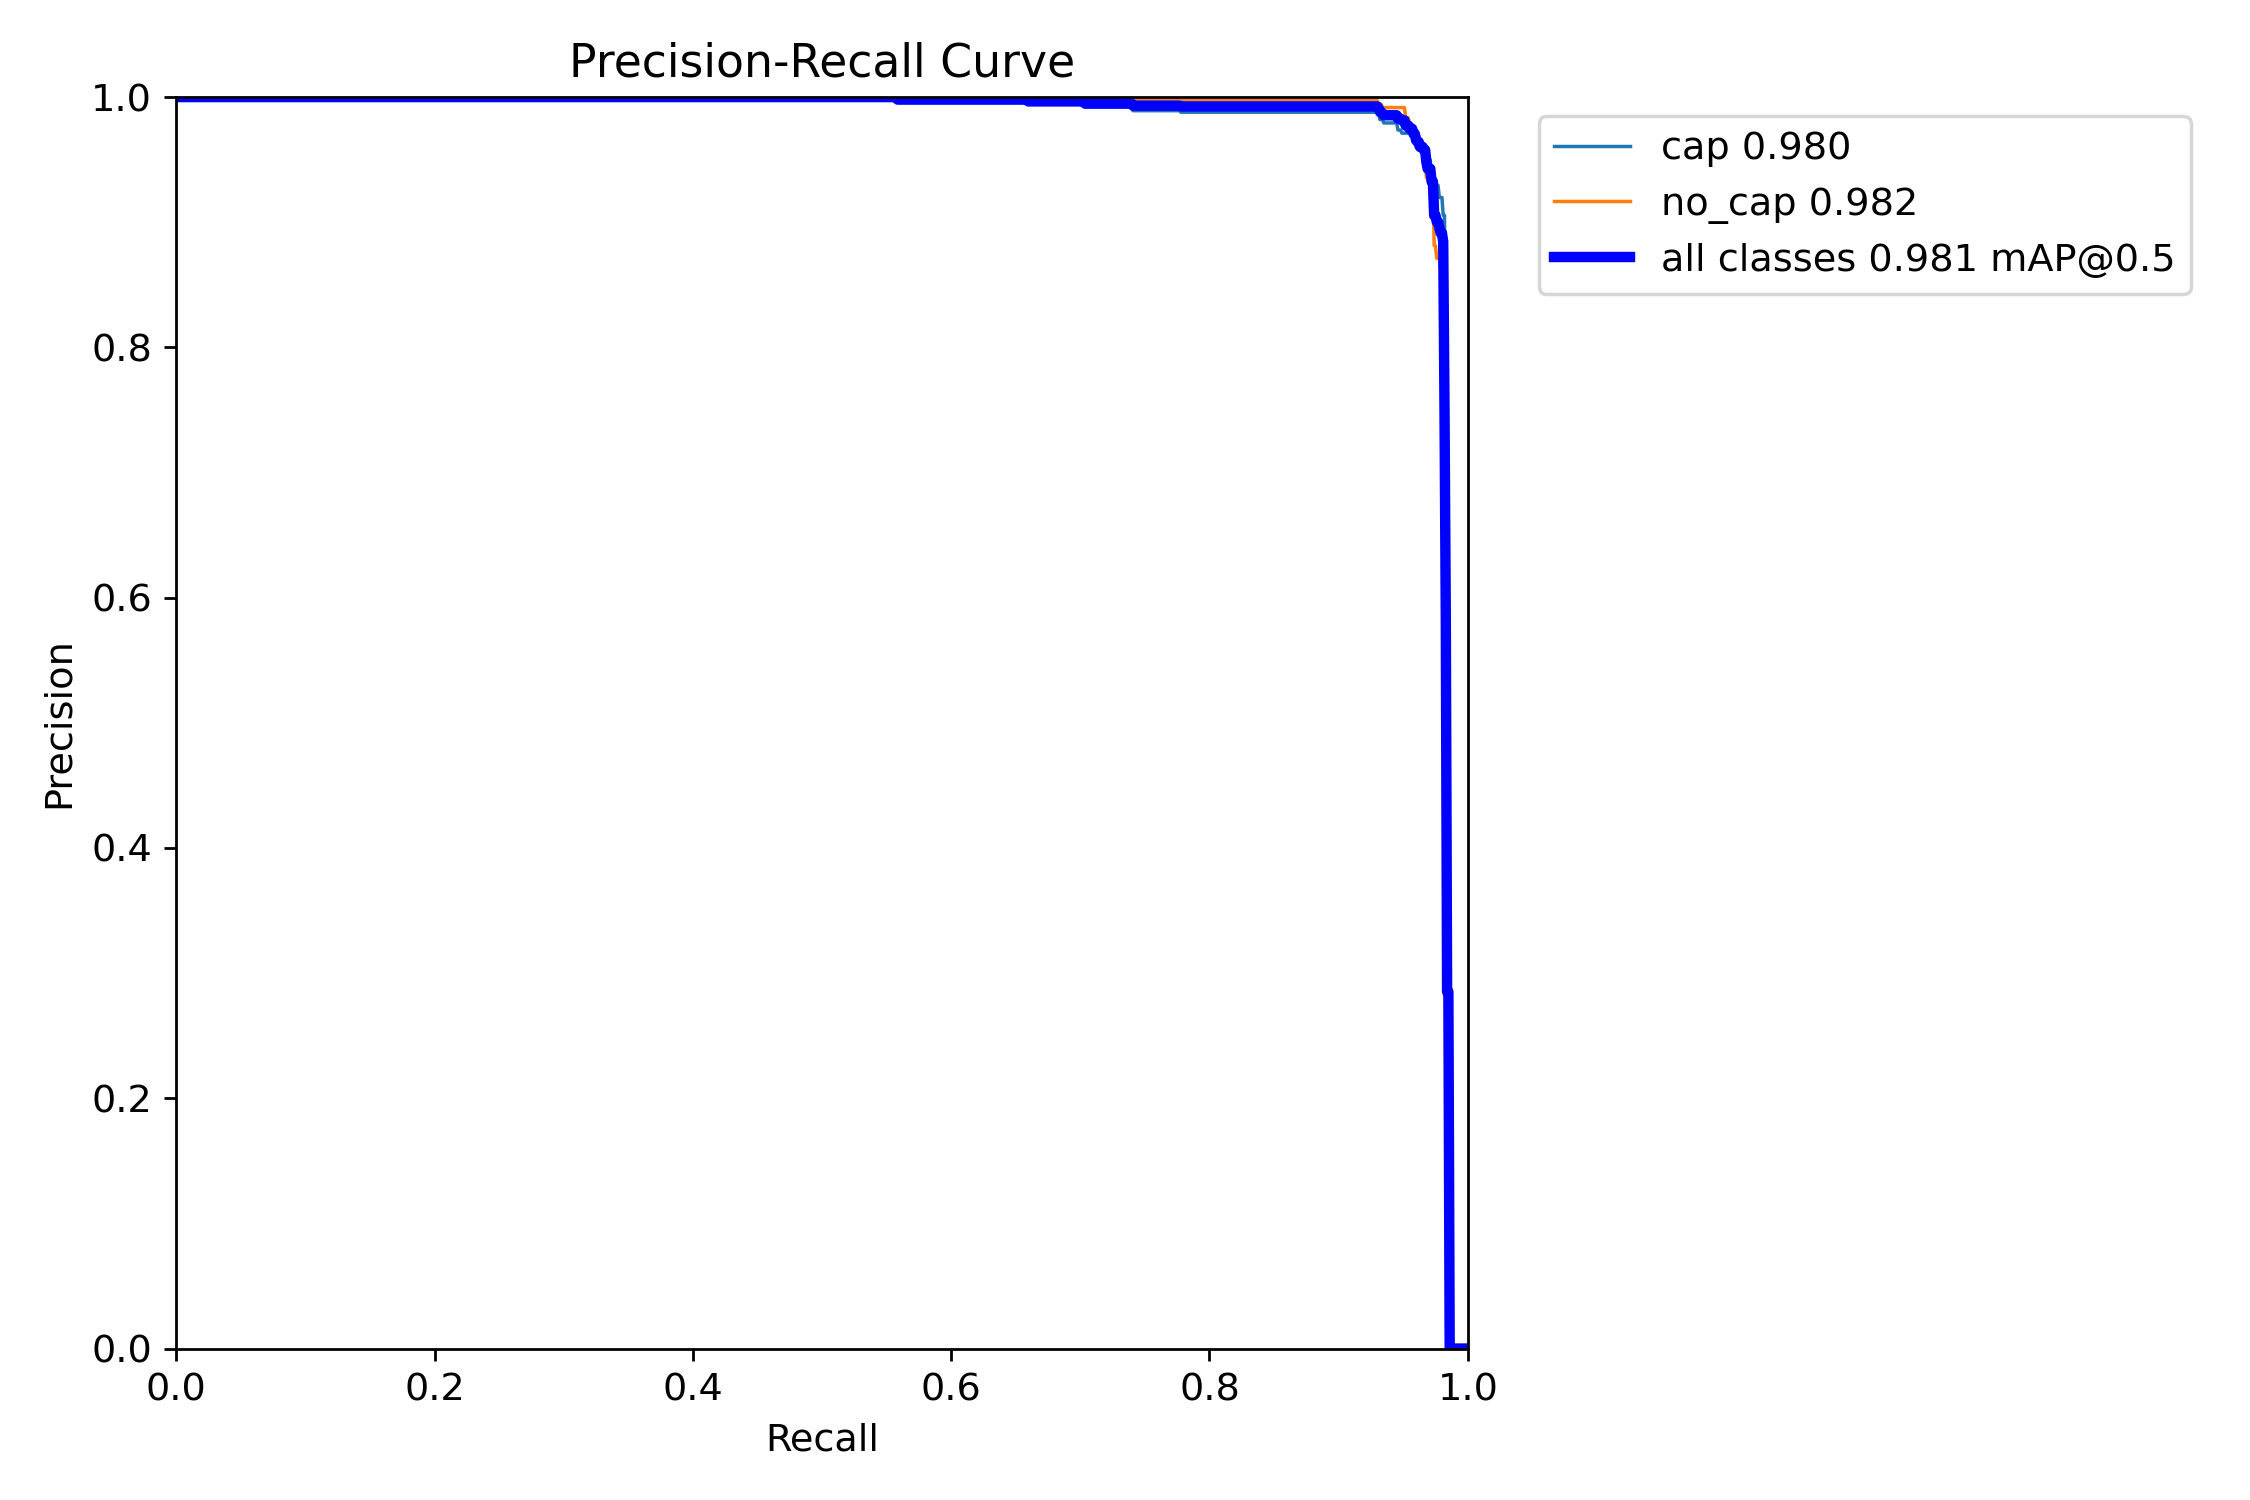

*v1 — Precision-Recall curve di TEST split.*


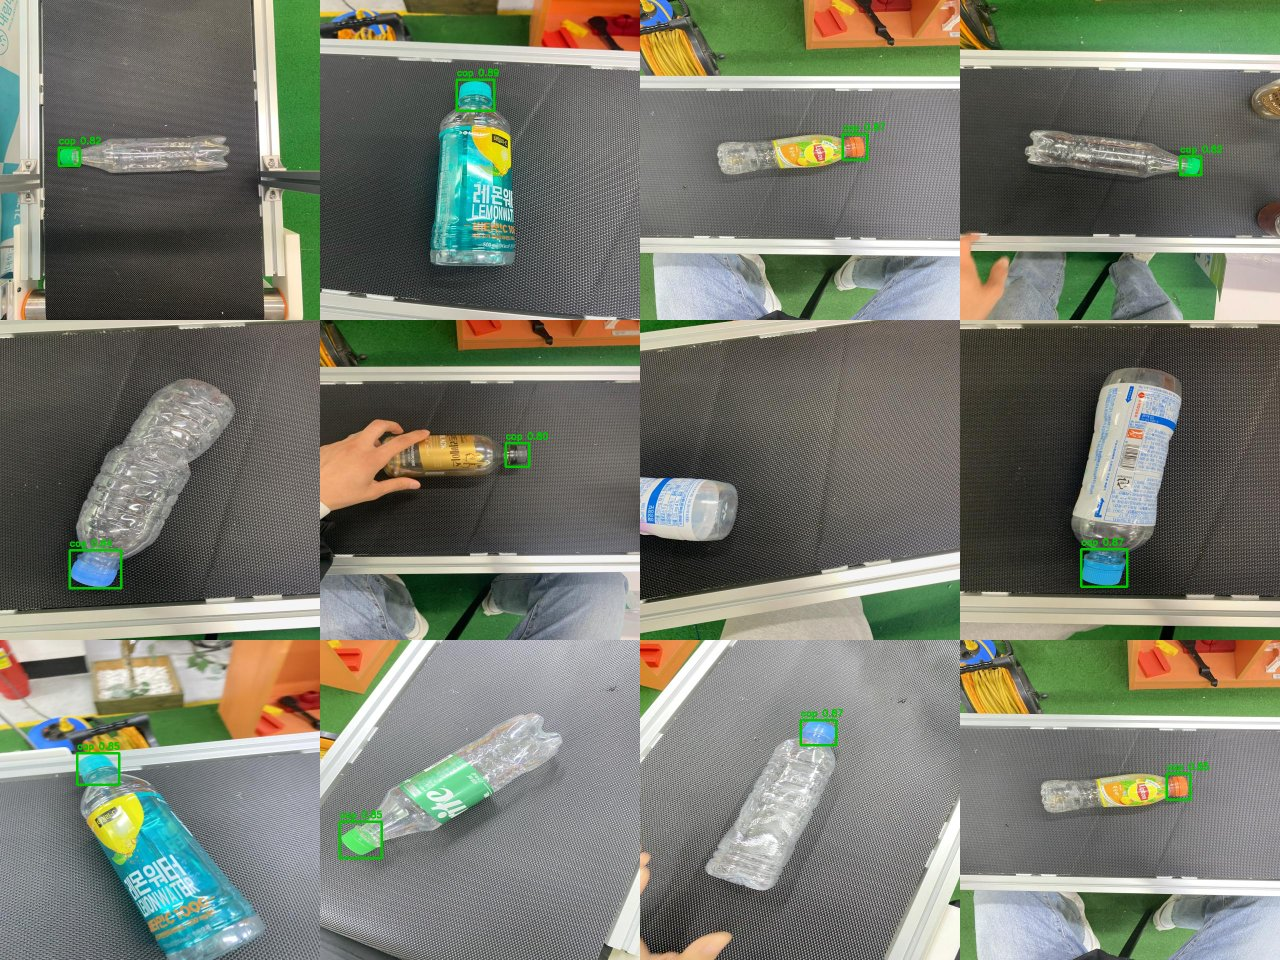

*v1 di 12 foto conveyor top-down asli (belt hitam) — box ketat di area tutup, conf 0,80–0,89. Sumber sebagian tumpang tindih dg training.*


## 8. Iterasi v2 — `synth_cap_v2_640` (upaya perbaikan no_cap)

### 8.1 Motivasi & perubahan

Menargetkan temuan §7.4 (no_cap under-confident di kamera jelek):
- variasi **no_cap ×48**, cap ×26 → oversample no_cap
- fungsi baru `hard_degrade()` (down-res 120–300 px + blur + motion blur + noise +
  JPEG q 18–46) diterapkan ke **~55 % sampel no_cap**
- simpan JPEG no_cap di kualitas 22–70 (cap tetap 38–95)

### 8.2 Komposisi dataset v2

| split | gambar | box cap | box no_cap |
|---|---|---|---|
| train | 5.202 | 2.465 | 3.362 |
| val | 565 | 249 | 386 |
| test | 744 | 344 | 507 |
| **TOTAL** | **6.511** | **3.058** | **4.255** |

Durasi training: **1,9 jam** / 100 epoch.

### 8.3 Hasil

| | P | R | mAP@50 | mAP@50-95 |
|---|---|---|---|---|
| **val** (best.pt) | 0,976 | 0,969 | 0,985 | 0,750 |
| — cap | 0,966 | 0,988 | 0,991 | 0,779 |
| — no_cap | 0,987 | 0,950 | 0,979 | 0,720 |
| **test** (744 img) | 0,968 | 0,951 | 0,979 | 0,724 |
| — cap | 0,974 | 0,948 | 0,978 | 0,720 |
| — no_cap | 0,961 | 0,955 | 0,980 | 0,728 |

Confusion matrix val: cap↔no_cap tertukar hanya 1–2 %; error utama = background (miss/FP).

### 8.4 Kesimpulan v2: **GAGAL — v1 lebih baik**

- Metrik test v2 ≈ v1 (test set tidak mengandung kondisi "kamera jelek", jadi tidak bisa
  menunjukkan efek perubahan). A/B kecil (12 foto no_cap conveyor, bersih + didegradasi):
  v1 ≈ v2, tidak ada beda terukur.
- **Live A/B webcam v1 vs v2:** v2 **lebih buruk** — `no_cap` lebih sering terdeteksi sebagai `cap`.
- **Akar masalah (kesalahan desain augmentasi):** `hard_degrade` hanya diterapkan ke kelas
  `no_cap`. Model belajar **shortcut palsu**: "gambar tajam → cap, gambar buram → no_cap".
  Di webcam live yang relatif tajam, no_cap jadi tertarik ke cap. Kualitas gambar menjadi
  *cue* kelas — persis yang tidak diinginkan.
- Class skew ke no_cap tidak menolong karena kalah dominan oleh sinyal degradasi asimetris.

**Keputusan: model produksi tetap v1.** v2 disimpan hanya untuk pembanding.

---


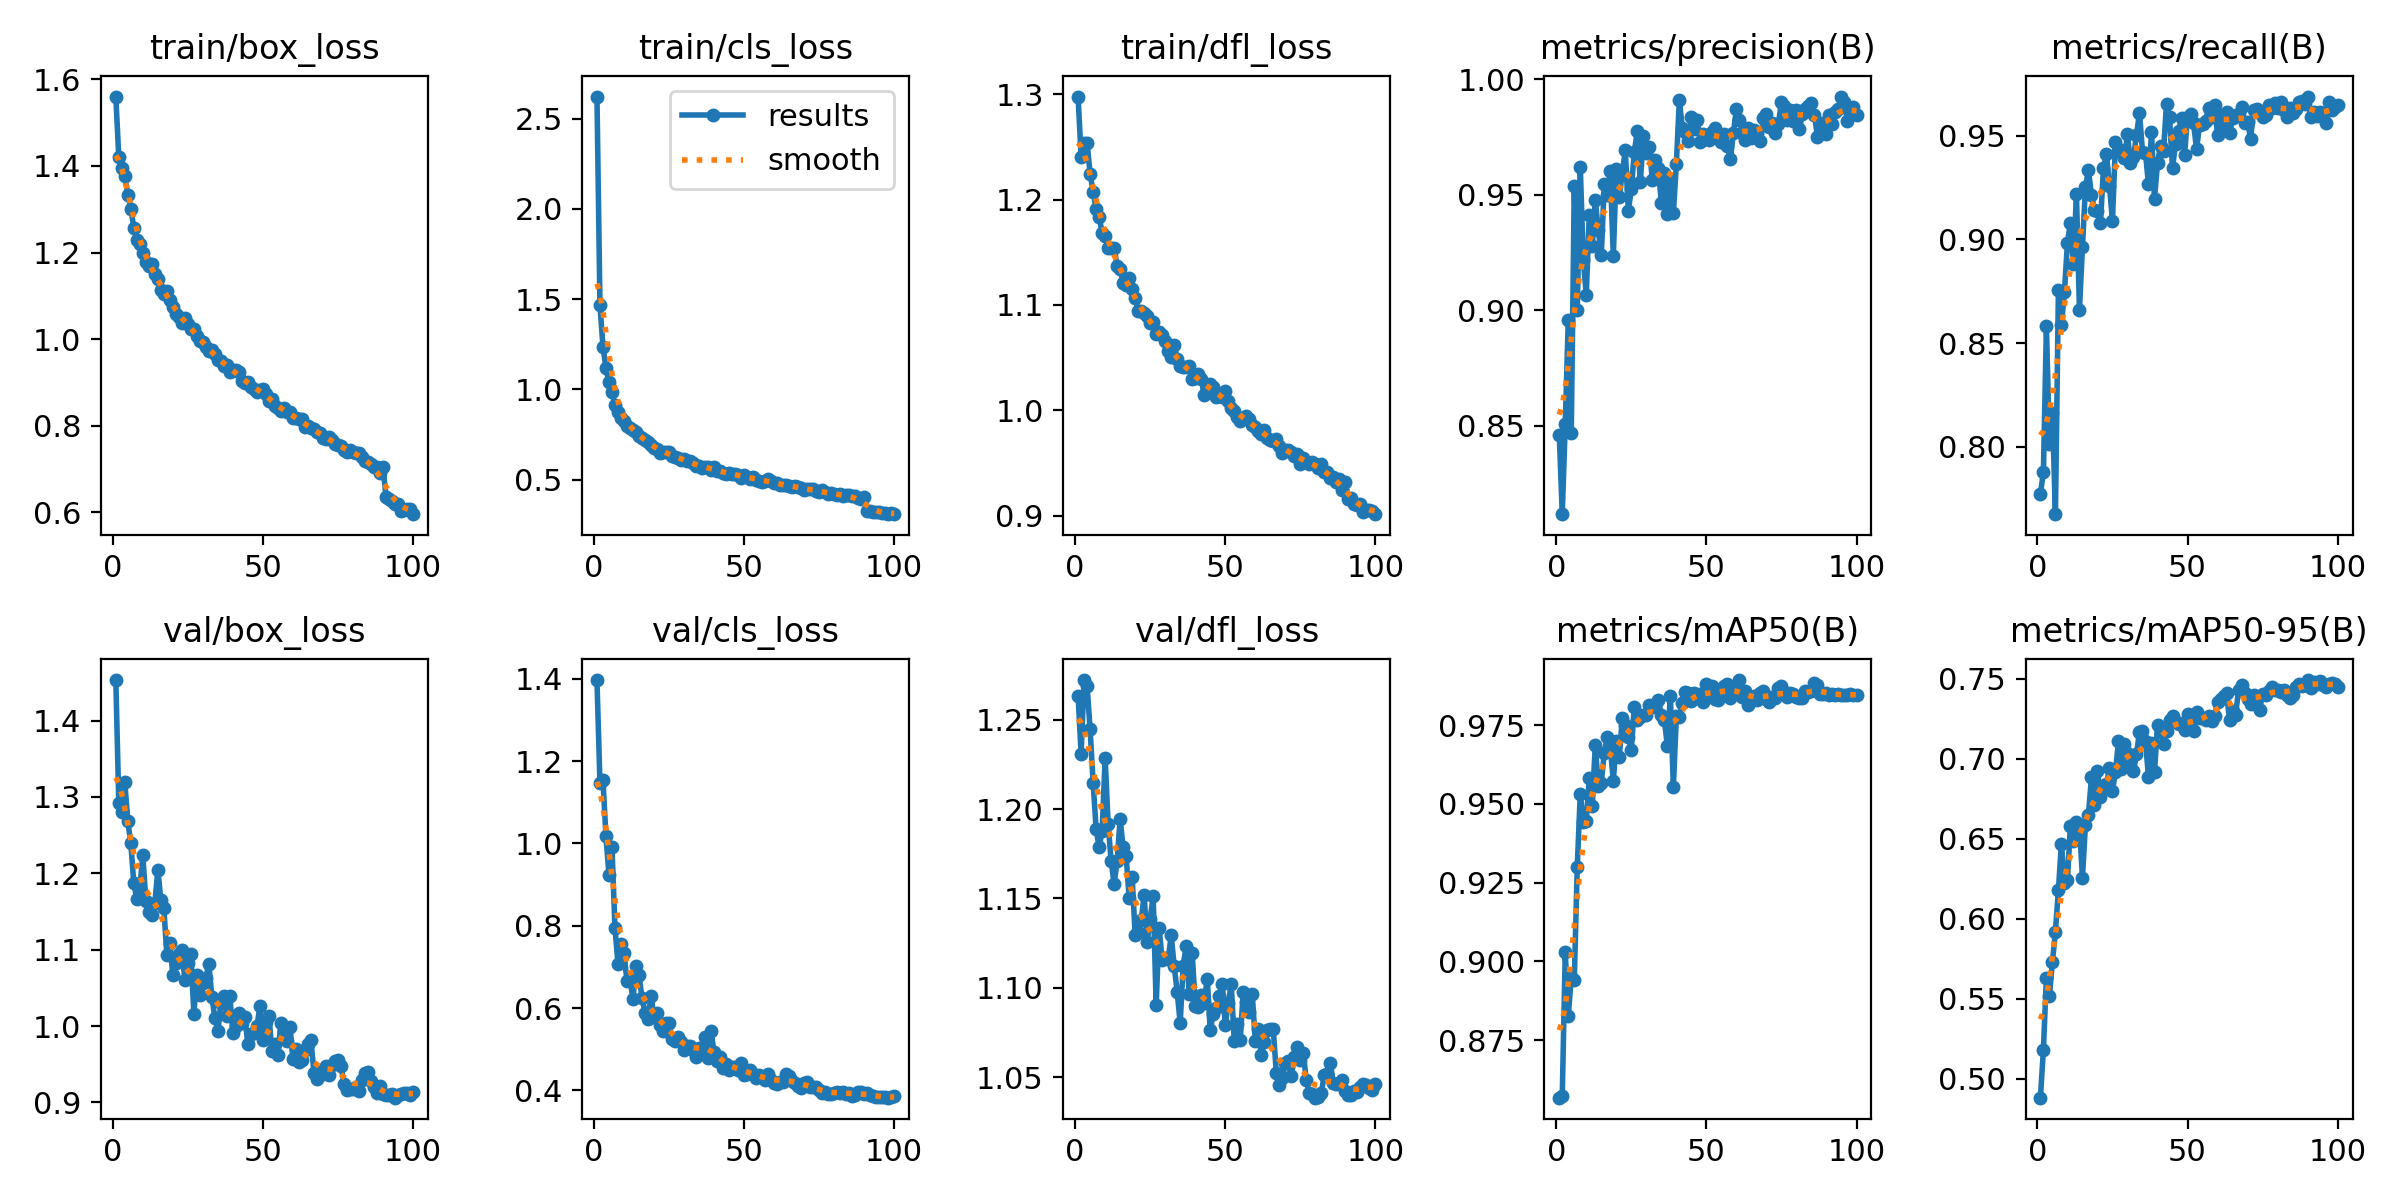

*v2 — kurva training 100 epoch.*


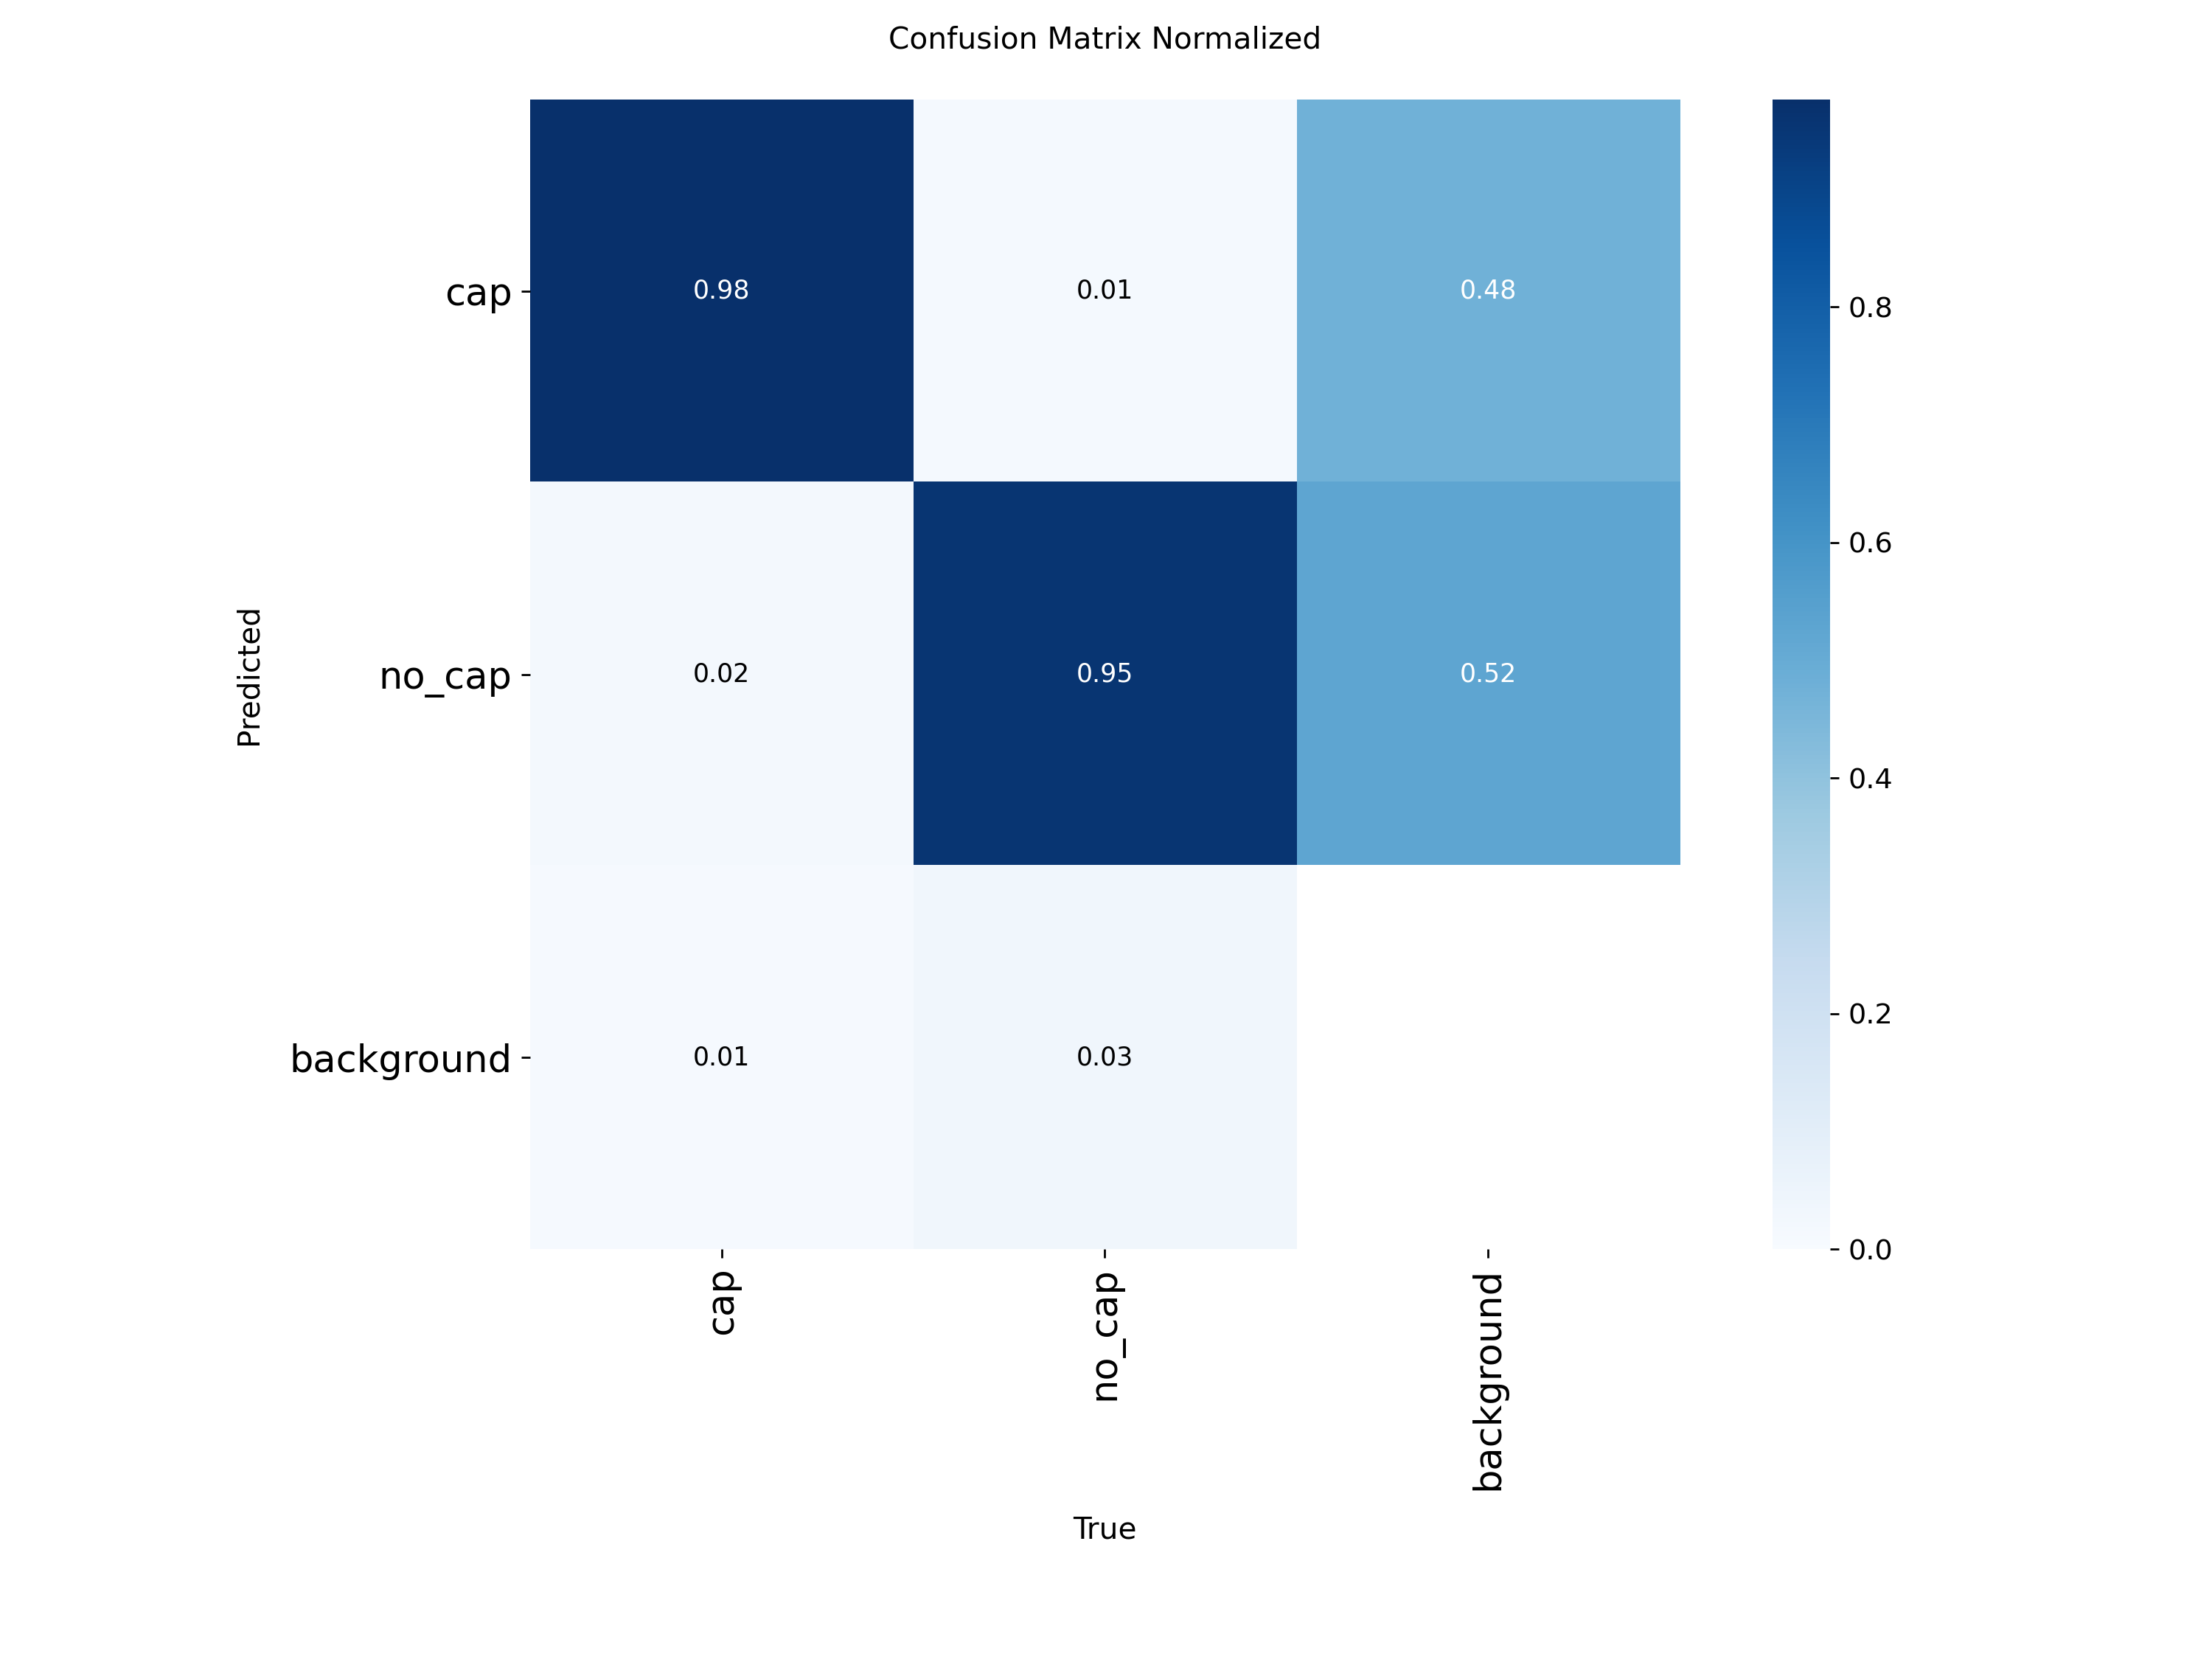

*v2 — confusion matrix (val). cap↔no_cap tertukar hanya 1–2%.*


## 9. Iterasi v3 — `synth_cap_v3_640` (perbaikan kesalahan v2)

### 9.1 Perubahan

Memperbaiki akar masalah v2 (§8.4):

| aspek | v2 (gagal) | v3 |
|---|---|---|
| `hard_degrade` diterapkan ke | **hanya `no_cap`**, p 0,55 | **`cap` & `no_cap` sama rata**, p 0,40 — kualitas gambar tidak lagi jadi *cue* kelas |
| intensitas down-res | 120–300 px | 150–360 px (lebih lembut) |
| oversample `no_cap` | ×48 vs cap ×26 (agresif) | ×44 vs cap ×30 (~1,5×, moderat) |
| JPEG save quality | no_cap 22–70 / cap 38–95 (terpisah) | 30–92 (sama untuk keduanya) |
| epoch | 100, patience 30 | **70, patience 20** (bukti plateau v1/v2 mendukung) |

### 9.2 Komposisi dataset v3

| split | gambar | box cap | box no_cap |
|---|---|---|---|
| train | 5.186 | 2.729 | 3.145 |
| **TOTAL** | **6.491** | **3.389** | **3.965** (skew ~54 %) |

Durasi training: **1,33 jam** / 70 epoch.

### 9.3 Hasil

| | P | R | mAP@50 | mAP@50-95 |
|---|---|---|---|---|
| **val** (best.pt, 565 img) | 0,971 | 0,954 | 0,979 | 0,750 |
| — cap | 0,971 | 0,951 | 0,980 | 0,759 |
| — no_cap | 0,972 | 0,958 | 0,979 | 0,741 |
| **test** (740 img) | 0,941 | 0,948 | 0,967 | 0,711 |
| — cap | 0,940 | 0,949 | 0,965 | 0,684 |
| — no_cap | 0,942 | 0,948 | 0,968 | 0,738 |

Metrik "bersih" v3 sedikit lebih rendah dari v1 — **wajar**: test set v3 mengandung ~40 %
gambar terdegradasi (kedua kelas), jadi bukan perbandingan apple-to-apple dengan test set v1.
Positifnya: performa `cap` dan `no_cap` kini **seimbang** (tidak ada asimetri seperti v2).

### 9.4 A/B v1 vs v3

- **Offline**, 12 foto `no_cap` conveyor asli + 60 `cap`, versi bersih & didegradasi buatan
  (down-res 220 px, JPEG q32):

  | kondisi degraded | v1 | v3 |
  |---|---|---|
  | `no_cap` mean confidence | 0,777 | **0,828** ↑ |
  | `cap` benar (dari 60) | 53 | **57** ↑ |

  → v3 mempertahankan confidence lebih baik saat gambar buram, untuk **kedua** kelas
  (degradasi simetris bekerja; sampel `no_cap` kecil).

- **Live webcam A/B (v1 kiri, v3 kanan):** **v1 tetap lebih robust.** v3 tidak lebih baik
  di feed webcam nyata.

### 9.5 Kesimpulan v3: tidak mengalahkan v1

Penyebab v3 kalah di live meski metrik degraded-offline naik:
- A/B offline memakai degradasi **buatan** (down-res + blur + JPEG). Artefak webcam nyata
  berbeda (noise sensor, autofocus, motion blur) — v3 belajar tahan ke degradasi buatan,
  bukan ke degradasi webcam.
- YOLOv8n hanya 3 juta parameter. Menambah ~40 % gambar terdegradasi memakai kapasitas
  model untuk fitur *degraded* → fitur kondisi bersih melemah. Feed webcam nyata lebih
  dekat ke "bersih" daripada ke `hard_degrade` yang brutal → v1 menang.

**Keputusan: model produksi tetap v1 (`synth_cap_v1_640/weights/best.pt`).**

---


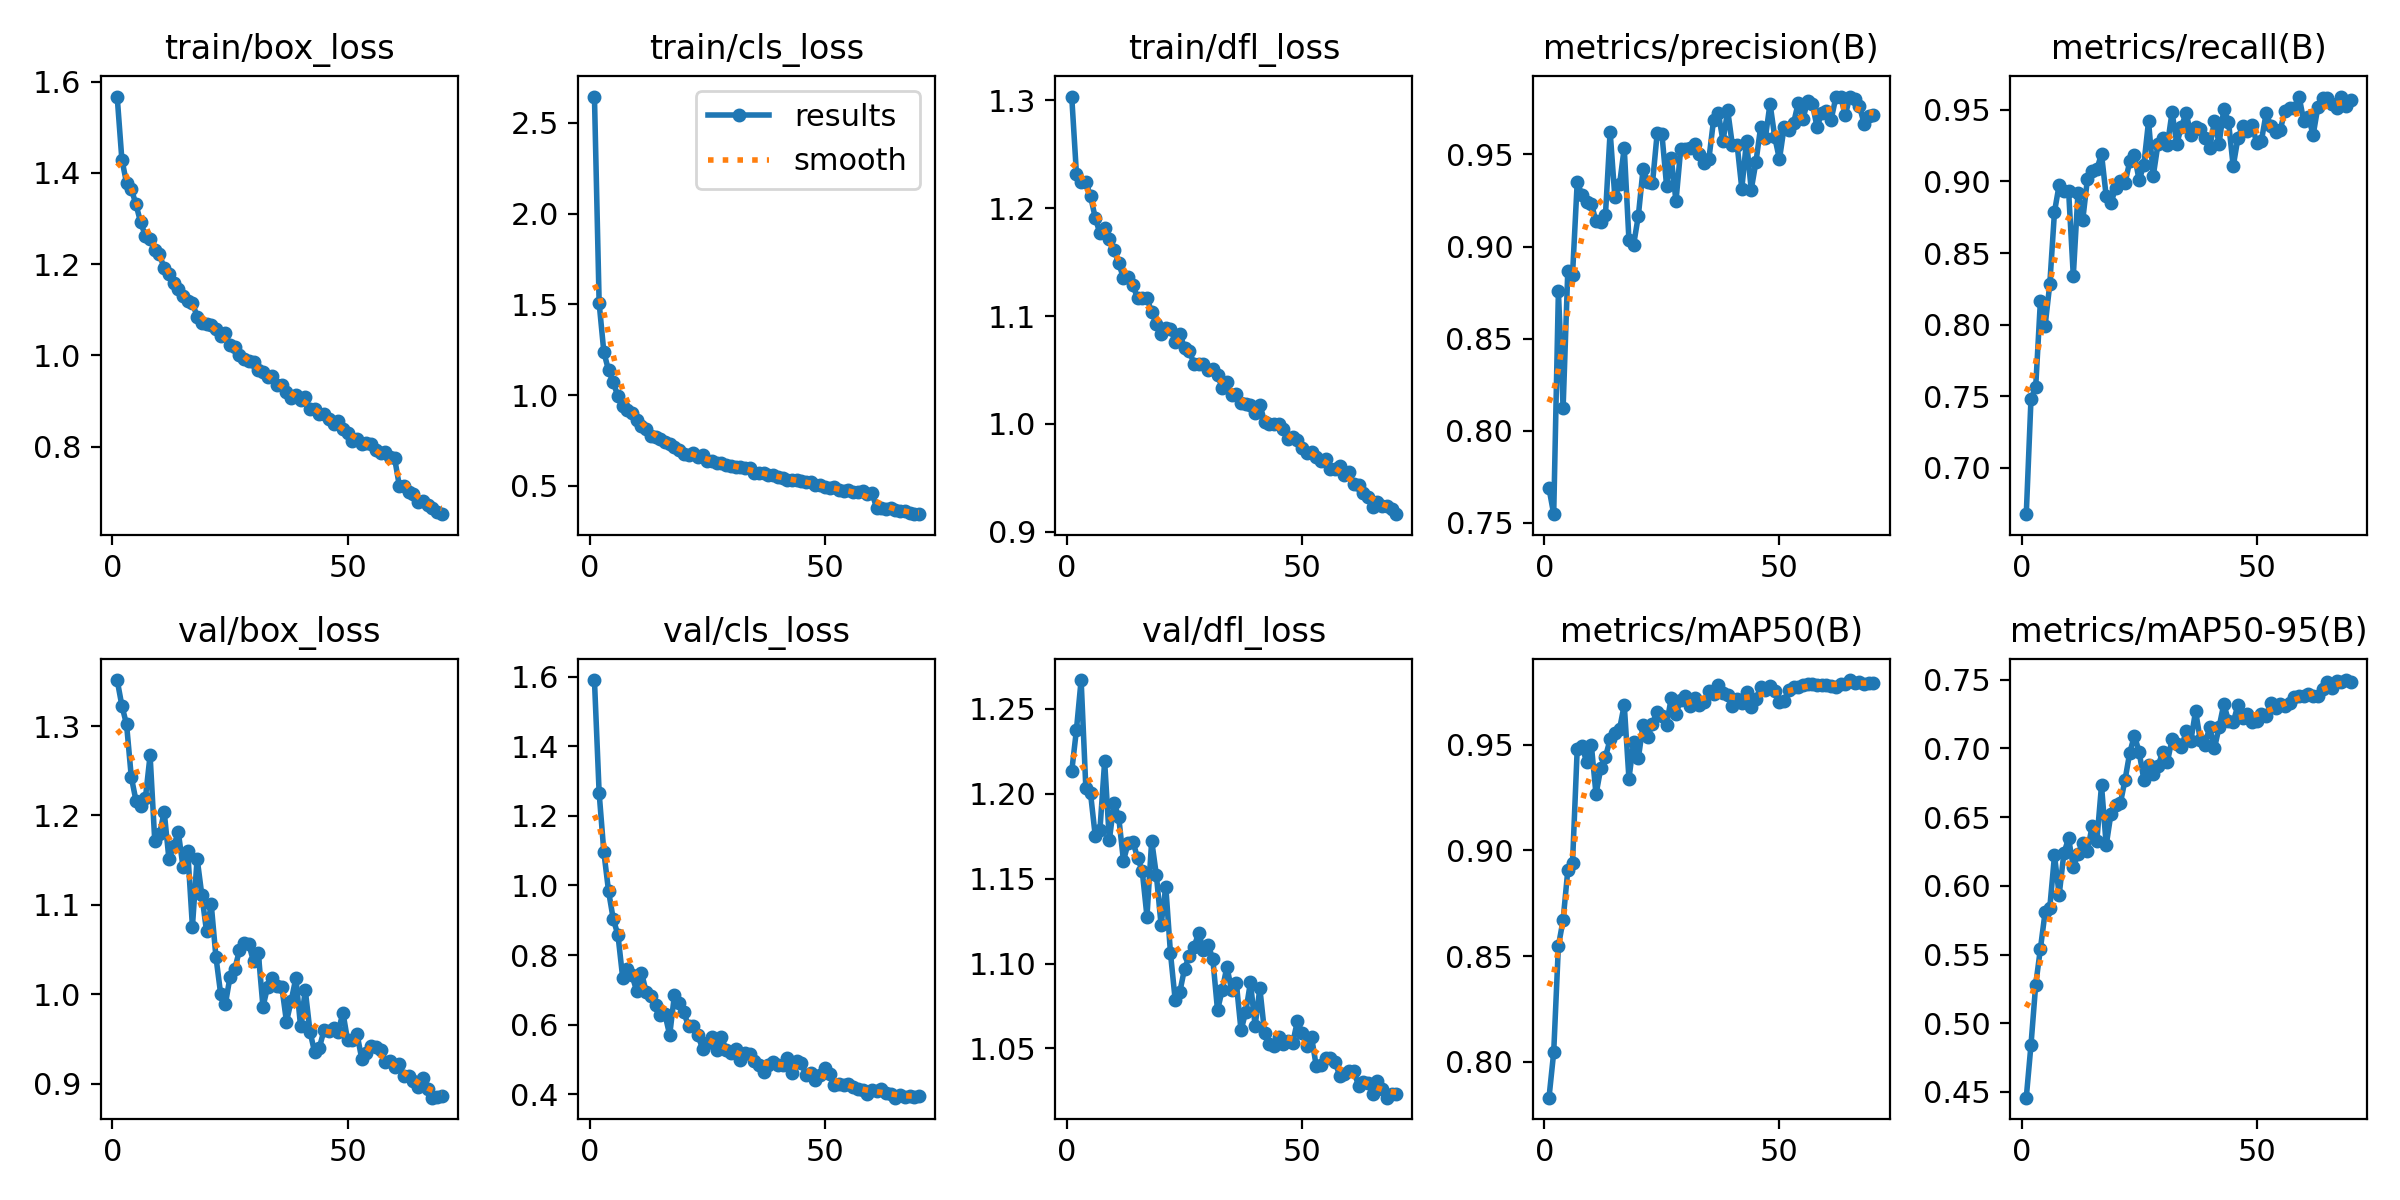

*v3 — kurva training 70 epoch (degradasi simetris cap & no_cap).*


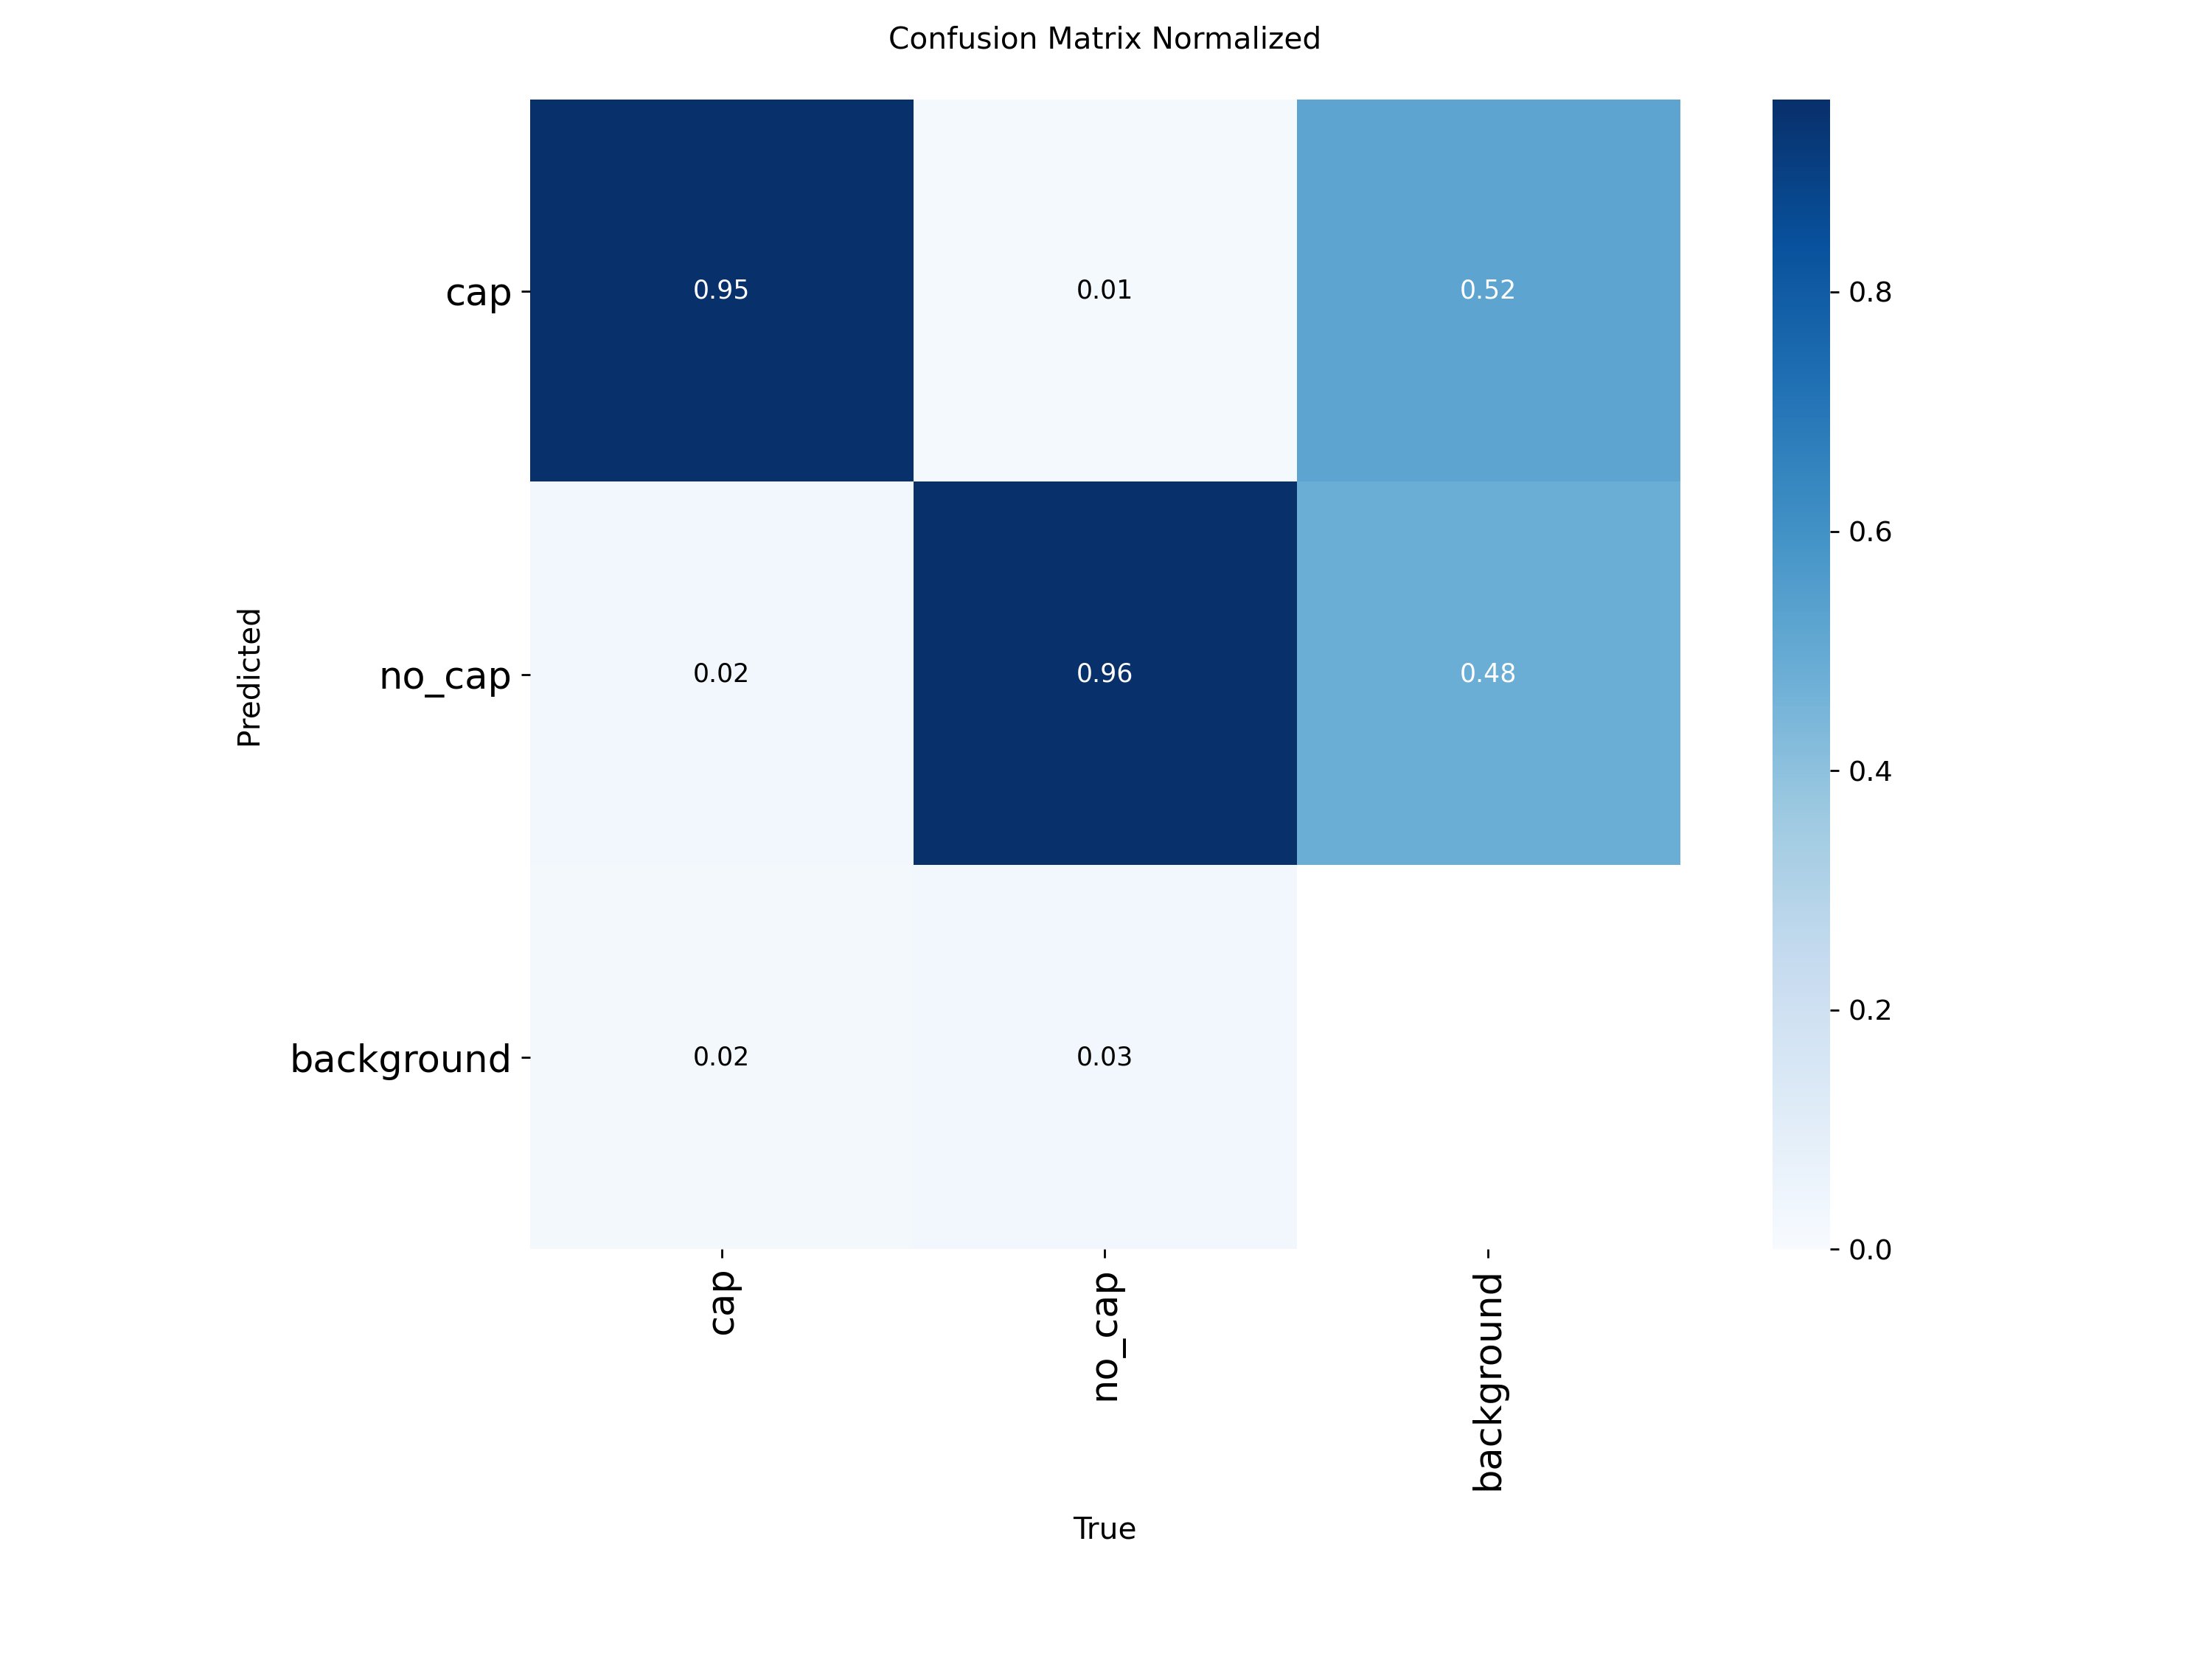

*v3 — confusion matrix (val). Performa cap & no_cap seimbang.*


## 10. Artefak & lokasi file

Semua di bawah `datasets/`:

| path | isi |
|---|---|
| `shoot_v1_raw/` | 260 foto 108 MP asli (arsip) |
| `shoot_v1/` | 260 foto 2 MP per-botol + label .json manual + MANIFEST.csv |
| `cap_shoot_v1/` | 260 gambar + 260 label YOLO (dataset primer bersih) |
| `cap_shoot_v1_cutout/nohand/` | 78 cutout RGBA top-down + `labels/` |
| `cap_shoot_v1_cutout/held_nohand/` | 71 cutout salvage + `_marginal/` 42 + `_damaged/` 63 + `_hand_residual/` 6 |
| `cap_shoot_v1_cutout/held/` | 182 cutout mentah (ada tangan) |
| `synth_cap_v1/` | dataset sintetis v1 — 5.731 gambar + data.yaml |
| `synth_cap_v2/` | dataset sintetis v2 — 6.511 gambar + data.yaml |
| `synth_cap_v3/` | dataset sintetis v3 — 6.491 gambar + data.yaml |
| `cap_runs/synth_cap_v1_640/` | **run produksi** — weights/best.pt, weights/best_openvino_model/, results.png, confusion_matrix*, PR/F1 curves |
| `cap_runs/synth_cap_v1_640_test/` | metrik & plot di test split |
| `cap_runs/synth_cap_v2_640/` | run v2 (pembanding, tidak dipakai) |
| `cap_runs/synth_cap_v3_640/` | run v3 (pembanding, tidak dipakai) |

### Script

| file | fungsi |
|---|---|
| `rename_shoot.py` | rapikan 260 foto → folder per-botol + MANIFEST |
| `label_shoot.py` | auto-label awal (COCO bottle box) — sebelum koreksi manual |
| `cap_box_shoot.py` | percobaan auto cap-box heuristik (ditolak) |
| `cutout_shoot.py` | cutout `rembg` + split nohand/held by nomor slot + transform label |
| `salvage_held.py` | buang tangan dari cutout held (person-seg + HSV), partisi by kept_frac |
| `verify_nohand.py` | verifikasi akhir bebas tangan pada 149 cutout |
| `make_synth.py` | compositing + augmentasi + grouped split → dataset sintetis |
| `add_conveyor.py` | fold-in conveyor cap balanced per warna + tulis data.yaml |
| `add_nocap.py` | fix-up: fold-in 109 conveyor no_cap |
| `train_synth.py` | training YOLOv8n + eval test + ekspor OpenVINO |
| `live_cap_test.py` | uji live webcam 1 model |
| `live_ab_test.py` | uji live webcam A/B 2 model split-screen (default v1 vs v3; run bisa dipilih via argumen) |
| `keep_awake.py` | cegah laptop sleep selama job panjang (ctypes, non-permanen) |

---


## 11. Kesimpulan

1. **Pipeline cut-and-paste + background generate berhasil**: dari 149 cutout botol milik
   sendiri + 943 gambar conveyor asli, model YOLOv8n (v1) mencapai mAP@50 **0,981** dan
   recall **0,947** di test split.
2. Model **kuat di POV top-down** (target deployment), **lemah di POV lain** (mis. webcam
   sejajar mata) — sesuai ekspektasi karena distribusi training.
3. **Dua iterasi perbaikan sintetis (v2, v3) tidak mengalahkan v1 di uji live:**
   - v2 gagal karena kesalahan desain — degradasi hanya di `no_cap` membuat kualitas gambar
     jadi *cue* kelas ("tajam → cap").
   - v3 memperbaiki desain (degradasi simetris) dan menang tipis di A/B **offline**, tetapi
     kalah di webcam nyata: degradasi buatan ≠ artefak webcam, dan model nano kehabisan
     kapasitas saat dipaksa belajar kondisi terdegradasi.
   - **Pelajaran:** knob-tuning augmentasi sintetis sudah mencapai batasnya untuk kasus ini.
     Peningkatan selanjutnya harus datang dari **data domain nyata**, bukan sintetis.
4. Semua angka evaluasi masih dari data sintetis + proxy conveyor. **Belum ada evaluasi di
   belt hijau + kamera mesin sebenarnya** — ini syarat sebelum model dianggap siap produksi.

**Model final: v1 (`cap_runs/synth_cap_v1_640/weights/best.pt` + `best_openvino_model/`).**


## 12. Rekomendasi lanjutan

| prioritas | langkah |
|---|---|
| Tinggi | **Ambil data asli**: foto `no_cap` (dan `cap`) di belt hijau + kamera mesin, ≥ 150–300, berbagai merek & kondisi, lalu retrain. Ini satu-satunya jalur peningkatan yang tersisa — tweak sintetis sudah terbukti mentok (v2, v3). |
| Tinggi | Labeli sebagian `cap_conveyor_raw/` (3.018 foto, di luar training) sebagai **holdout evaluasi domain asli** untuk mengukur v1 secara jujur. |
| Sedang | Post-rule di decision logic: jika prediksi `cap` tapi margin ke `no_cap` < ~0,2 → status "ragu" → re-scan / reject. Murah, tidak perlu retrain. |
| Rendah | Isu no_cap-under-confident kemungkinan besar hilang di kamera mesin asli (fixed focus, cahaya terkontrol, top-down) — verifikasi dulu di hardware sebelum investasi lebih jauh. |
| Rendah | Konversi `best.pt` untuk target Jetson pakai **TensorRT** (OpenVINO tidak jalan di ARM+NVIDIA). |


## 13. Catatan reproduksibilitas

Urutan menjalankan ulang pipeline v1 (dari `datasets/`, venv aktif):

```bash
python cutout_shoot.py       # 260 foto -> cutout + label
python salvage_held.py       # buang tangan dari cutout held
python verify_nohand.py      # verifikasi bebas tangan
python make_synth.py         # compositing -> synth_cap_v1/
python add_conveyor.py       # fold-in conveyor cap + data.yaml
python add_nocap.py          # fold-in conveyor no_cap
python train_synth.py        # train + eval test + export OpenVINO
```

Seed 0 dipakai di semua tahap; hasil deterministik kecuali variasi kecil dari CUDA/cuDNN.
